In [ ]:
import numpy as np #linear algebra
import pandas as pd #datapreprocessing, CSV file I/O
import seaborn as sns #for plotting graphs
import matplotlib.pyplot as plt

#load necessary modules 
%matplotlib inline
import scipy.stats as stats
import statsmodels.formula.api as smf
import statsmodels.stats.api as sms
import statsmodels.api as sm
from statsmodels.formula.api import ols
from sklearn import datasets, linear_model
import seaborn as sns
from sklearn import preprocessing
from sklearn.preprocessing import LabelEncoder
from sklearn import metrics
from sklearn.metrics import r2_score
from sklearn.metrics import mean_squared_error, make_scorer
from sklearn.model_selection import cross_val_score
from sklearn.feature_selection import RFE
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

## Import the data

In [ ]:
import os 

In [ ]:
# Revise the path to the folder that contains the data set
os.chdir('/Users/zihongxiong/desktop/3510_data')

In [ ]:
df_Security = pd.read_csv("Securities_1Year.csv")

/Users/zihongxiong/opt/anaconda3/lib/python3.8/site-packages/IPython/core/interactiveshell.py:3165: DtypeWarning: Columns (1) have mixed types.Specify dtype option on import or set low_memory=False.
  has_raised = await self.run_ast_nodes(code_ast.body, cell_name,


In [ ]:
df_Fundamental = pd.read_excel("CompanyFundamental.xlsx")

## Go through the basic information for each data set

In [ ]:
df_Security.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4999490 entries, 0 to 4999489
Data columns (total 23 columns):
 #   Column    Dtype  
---  ------    -----  
 0   gvkey     int64  
 1   iid       object 
 2   datadate  object 
 3   tic       object 
 4   conm      object 
 5   anncdate  object 
 6   paydate   object 
 7   cshoc     float64
 8   dvi       float64
 9   eps       float64
 10  prccd     float64
 11  prchd     float64
 12  prcld     float64
 13  prcod     float64
 14  exchg     int64  
 15  cik       float64
 16  ggroup    float64
 17  gind      float64
 18  gsector   float64
 19  gsubind   float64
 20  naics     float64
 21  sic       float64
 22  ipodate   object 
dtypes: float64(14), int64(2), object(7)
memory usage: 877.3+ MB


In [ ]:
df_Fundamental.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 164379 entries, 0 to 164378
Data columns (total 92 columns):
 #   Column    Non-Null Count   Dtype         
---  ------    --------------   -----         
 0   gvkey     164379 non-null  int64         
 1   conm      164379 non-null  object        
 2   fyear     164379 non-null  int64         
 3   indfmt    164379 non-null  object        
 4   datafmt   164379 non-null  object        
 5   tic       164361 non-null  object        
 6   fyr       164379 non-null  int64         
 7   act       57474 non-null   float64       
 8   aedi      1667 non-null    float64       
 9   aldo      60057 non-null   float64       
 10  amc       360 non-null     float64       
 11  amgw      9998 non-null    float64       
 12  ao        78881 non-null   float64       
 13  aqc       65507 non-null   float64       
 14  aqp       18048 non-null   float64       
 15  aqs       7881 non-null    float64       
 16  arce      0 non-null       float64    

In [ ]:
#Display thr first 5 rows of the Securities_1st_year data
pd.options.display.max_columns = None
df_Security.head(5)

,gvkey,iid,datadate,tic,conm,anncdate,paydate,cshoc,dvi,eps,prccd,prchd,prcld,prcod,exchg,cik,ggroup,gind,gsector,gsubind,naics,sic,ipodate
0,1004,01,01/03/2023,AIR,AAR CORP,NaN,NaN,34455000.0,0.0,2.57,44.60,45.58,44.21,45.09,11,1750.0,2010.0,201010.0,20.0,20101010.0,423860.0,5080.0,04/24/1972
1,1004,01,01/04/2023,AIR,AAR CORP,NaN,NaN,34455000.0,0.0,2.57,45.24,45.66,44.56,44.56,11,1750.0,2010.0,201010.0,20.0,20101010.0,423860.0,5080.0,04/24/1972
2,1004,01,01/05/2023,AIR,AAR CORP,NaN,NaN,34455000.0,0.0,2.57,44.82,45.04,44.50,44.86,11,1750.0,2010.0,201010.0,20.0,20101010.0,423860.0,5080.0,04/24/1972
3,1004,01,01/06/2023,AIR,AAR CORP,NaN,NaN,34455000.0,0.0,2.57,46.09,46.52,45.20,45.20,11,1750.0,2010.0,201010.0,20.0,20101010.0,423860.0,5080.0,04/24/1972
4,1004,01,01/09/2023,AIR,AAR CORP,NaN,NaN,34455000.0,0.0,2.57,46.18,47.15,45.94,46.84,11,1750.0,2010.0,201010.0,20.0,20101010.0,423860.0,5080.0,04/24/1972


In [ ]:
#Display the first 5 rows of the CompanyFundamental data
pd.options.display.max_columns = None

df_Fundamental.head(5)

,gvkey,conm,fyear,indfmt,datafmt,tic,fyr,act,aedi,aldo,amc,amgw,ao,aqc,aqp,aqs,arce,at,bast,bkvlps,cgti,ch,cogs,cshi,cstk,dd1,dd2,dd3,dd4,dd5,dltt,dp,dpact,dpc,dt,dv,dvt,ebit,ebitda,emp,epspi,gdwl,invt,ist,istm,lct,lt,ni,niint,nits,opeps,optprcgr,ppegt,ppent,prstkc,pstk,re,rect,revt,ris,sale,scstkc,seta,siv,sppe,teq,txp,uceq,unwcc,wcapch,xad,xagt,xcom,xopr,xpr,xrd,xsga,xstfws,xt,exchg,cik,costat,ggroup,gind,gsector,gsubind,idbflag,incorp,naics,sic,spcindcd,ipodate
0,1004,AAR CORP,2013,INDL,STD,AIR,5,1116.9,NaN,0.0,NaN,NaN,194.1,15.3,NaN,NaN,NaN,2199.5,NaN,25.2654,NaN,89.2,1581.4,44.674,44.7,69.7,70.8,10.0,130.0,25.0,564.3,113.4,424.3,113.4,634.0,11.8,11.8,142.6,256.0,5.80,1.85,261.7,632.9,NaN,NaN,402.1,1198.8,72.9,NaN,NaN,1.85,25.43,837.6,413.3,1.0,0.0,616.7,297.9,2035.0,NaN,2035.0,NaN,NaN,0.0,NaN,1000.7,0.0,NaN,NaN,NaN,NaN,NaN,NaN,1779.0,16.1,NaN,197.6,NaN,NaN,11.0,1750.0,A,2010.0,201010.0,20.0,20101010.0,D,DE,423860.0,5080,110.0,1972-04-24
1,1004,AAR CORP,2013,INDL,SUMM_STD,AIR,5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,11.0,1750.0,A,2010.0,201010.0,20.0,20101010.0,D,DE,423860.0,5080,110.0,1972-04-24
2,1004,AAR CORP,2014,INDL,SUMM_STD,AIR,5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1454.1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.26,NaN,NaN,NaN,NaN,NaN,NaN,10.2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1448.0,NaN,NaN,NaN,NaN,845.1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,11.0,1750.0,A,2010.0,201010.0,20.0,20101010.0,D,DE,423860.0,5080,110.0,1972-04-24
3,1004,AAR CORP,2014,INDL,STD,AIR,5,954.1,NaN,0.0,NaN,NaN,68.7,1.0,NaN,NaN,NaN,1515.0,NaN,23.8574,NaN,54.7,1342.7,44.896,44.9,69.0,10.0,0.0,25.0,50.0,85.0,92.3,398.5,123.9,154.0,12.5,11.9,-8.6,83.7,4.85,0.26,123.5,566.7,NaN,NaN,412.0,669.9,10.2,NaN,NaN,-0.60,NaN,693.5,295.0,151.5,0.0,603.9,231.1,1594.3,NaN,1594.3,NaN,NaN,4.0,40.3,845.1,0.0,NaN,NaN,NaN,NaN,NaN,NaN,1510.6,14.9,NaN,167.9,NaN,NaN,11.0,1750.0,A,2010.0,201010.0,20.0,20101010.0,D,DE,423860.0,5080,110.0,1972-04-24
4,1004,AAR CORP,2015,INDL,SUMM_STD,AIR,5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1456.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,33.2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.37,NaN,NaN,NaN,NaN,NaN,NaN,47.7,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1525.4,NaN,NaN,NaN,NaN,865.8,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,157.6,NaN,NaN,11.0,1750.0,A,2010.0,201010.0,20.0,20101010.0,D,DE,423860.0,5080,110.0,1972-04-24


## Data Cleaning for 'CompanyFundamental' data  

In [ ]:
## Select Standard format

# Filter only the records where 'datafmt' is 'std'
df_FDMT_std = df_Fundamental[df_Fundamental['datafmt'] == 'STD']

df_FDMT_std.head(5)

,gvkey,conm,fyear,indfmt,datafmt,tic,fyr,act,aedi,aldo,amc,amgw,ao,aqc,aqp,aqs,arce,at,bast,bkvlps,cgti,ch,cogs,cshi,cstk,dd1,dd2,dd3,dd4,dd5,dltt,dp,dpact,dpc,dt,dv,dvt,ebit,ebitda,emp,epspi,gdwl,invt,ist,istm,lct,lt,ni,niint,nits,opeps,optprcgr,ppegt,ppent,prstkc,pstk,re,rect,revt,ris,sale,scstkc,seta,siv,sppe,teq,txp,uceq,unwcc,wcapch,xad,xagt,xcom,xopr,xpr,xrd,xsga,xstfws,xt,exchg,cik,costat,ggroup,gind,gsector,gsubind,idbflag,incorp,naics,sic,spcindcd,ipodate
0,1004,AAR CORP,2013,INDL,STD,AIR,5,1116.9,NaN,0.0,NaN,NaN,194.1,15.3,NaN,NaN,NaN,2199.5,NaN,25.2654,NaN,89.2,1581.4,44.674,44.7,69.7,70.8,10.0,130.0,25.0,564.3,113.4,424.3,113.4,634.0,11.8,11.8,142.6,256.0,5.80,1.85,261.7,632.9,NaN,NaN,402.1,1198.8,72.9,NaN,NaN,1.85,25.43,837.6,413.3,1.0,0.0,616.7,297.9,2035.0,NaN,2035.0,NaN,NaN,0.0,NaN,1000.7,0.0,NaN,NaN,NaN,NaN,NaN,NaN,1779.0,16.1,NaN,197.6,NaN,NaN,11.0,1750.0,A,2010.0,201010.0,20.0,20101010.0,D,DE,423860.0,5080,110.0,1972-04-24
3,1004,AAR CORP,2014,INDL,STD,AIR,5,954.1,NaN,0.0,NaN,NaN,68.7,1.0,NaN,NaN,NaN,1515.0,NaN,23.8574,NaN,54.7,1342.7,44.896,44.9,69.0,10.0,0.0,25.0,50.0,85.0,92.3,398.5,123.9,154.0,12.5,11.9,-8.6,83.7,4.85,0.26,123.5,566.7,NaN,NaN,412.0,669.9,10.2,NaN,NaN,-0.60,NaN,693.5,295.0,151.5,0.0,603.9,231.1,1594.3,NaN,1594.3,NaN,NaN,4.0,40.3,845.1,0.0,NaN,NaN,NaN,NaN,NaN,NaN,1510.6,14.9,NaN,167.9,NaN,NaN,11.0,1750.0,A,2010.0,201010.0,20.0,20101010.0,D,DE,423860.0,5080,110.0,1972-04-24
5,1004,AAR CORP,2015,INDL,STD,AIR,5,873.1,NaN,0.0,NaN,NaN,71.5,0.0,NaN,NaN,NaN,1442.1,NaN,25.0847,NaN,31.2,1354.9,44.868,44.9,12.0,1.9,26.2,110.2,0.0,136.1,70.8,417.3,70.8,148.1,10.4,10.4,66.1,136.9,4.70,1.37,117.3,563.7,NaN,NaN,329.0,576.3,47.7,NaN,NaN,1.10,26.62,731.2,313.9,18.8,0.0,637.2,242.7,1662.6,NaN,1662.6,NaN,NaN,0.0,NaN,865.8,1.1,NaN,NaN,NaN,NaN,NaN,NaN,1525.7,14.1,NaN,170.8,NaN,NaN,11.0,1750.0,A,2010.0,201010.0,20.0,20101010.0,D,DE,423860.0,5080,110.0,1972-04-24
6,1004,AAR CORP,2016,INDL,STD,AIR,5,888.5,NaN,0.0,NaN,NaN,76.5,12.5,NaN,NaN,NaN,1504.1,NaN,26.6112,NaN,10.3,1422.7,45.175,45.2,2.0,26.2,0.2,0.0,131.0,155.3,71.0,413.9,71.0,157.3,10.2,10.2,77.2,148.2,4.60,1.66,115.4,601.1,NaN,NaN,335.1,589.9,56.5,NaN,NaN,1.42,24.10,775.4,361.5,19.8,0.0,688.0,251.4,1767.6,NaN,1767.6,NaN,NaN,0.0,NaN,914.2,12.3,NaN,NaN,NaN,NaN,NaN,NaN,1619.4,15.3,NaN,196.7,NaN,NaN,11.0,1750.0,A,2010.0,201010.0,20.0,20101010.0,D,DE,423860.0,5080,110.0,1972-04-24
8,1004,AAR CORP,2017,INDL,STD,AIR,5,942.7,NaN,0.0,NaN,NaN,100.7,22.9,NaN,0.0,NaN,1524.7,NaN,26.9703,NaN,31.1,1413.2,45.301,45.3,0.0,0.0,0.0,153.9,0.0,177.2,40.5,214.4,40.5,177.2,10.3,10.3,86.0,126.5,5.00,0.44,118.7,547.9,NaN,NaN,333.3,588.4,15.6,NaN,NaN,1.73,35.33,531.0,316.6,13.1,0.0,701.2,203.0,1748.3,NaN,1748.3,NaN,NaN,0.0,NaN,936.3,0.0,NaN,NaN,NaN,NaN,NaN,NaN,1621.8,11.2,NaN,208.6,NaN,NaN,11.0,1750.0,A,2010.0,201010.0,20.0,20101010.0,D,DE,423860.0,5080,110.0,1972-04-24


In [ ]:
# Filter out unnecessary columns (clear up a little bit)
#Select variables with no more than 75% missing values

df_FDMT_clr = df_FDMT_std.loc[:, df_FDMT_std.isnull().mean() < 0.75]
df_FDMT_clr.head(5)

In [ ]:
# Aggregate financial columns for each company (gvkey) across all years
financial_columns = ['act', 'aldo','ao','aqc', 'at', 'bkvlps', 'ch', 'cogs', 'cshi', 'cstk', 'dd1', 'dd2', 'dd3',
                     'dd4','dd5','dltt','dp', 'dpact','dpc', 'dt', 'dv', 'dvt', 'ebit', 'ebitda', 'emp', 'epspi', 'gdwl',
                    'invt', 'lct', 'lt', 'ni', 'opeps','optprcgr', 'ppegt', 'ppent', 'prstkc','pstk', 're', 'rect', 'revt',
                    'sale', 'siv','teq', 'txp','xopr', 'xpr', 'xrd','xsga']
aggregated_stats = df_FDMT_clr.groupby('gvkey')[financial_columns].agg(['mean', 'std']).reset_index()

In [ ]:
# Selecting Categorical data
categorical_stats = df_FDMT_clr.drop(financial_columns, axis=1)

categorical_stats.head(3)

,gvkey,conm,fyear,indfmt,datafmt,tic,fyr,sppe,exchg,cik,costat,ggroup,gind,gsector,gsubind,idbflag,incorp,naics,sic,spcindcd,ipodate
0,1004,AAR CORP,2013,INDL,STD,AIR,5,NaN,11.0,1750.0,A,2010.0,201010.0,20.0,20101010.0,D,DE,423860.0,5080,110.0,1972-04-24
3,1004,AAR CORP,2014,INDL,STD,AIR,5,40.3,11.0,1750.0,A,2010.0,201010.0,20.0,20101010.0,D,DE,423860.0,5080,110.0,1972-04-24
5,1004,AAR CORP,2015,INDL,STD,AIR,5,NaN,11.0,1750.0,A,2010.0,201010.0,20.0,20101010.0,D,DE,423860.0,5080,110.0,1972-04-24


In [ ]:
# Sort by 'gvkey' and 'fyear' to ensure the latest year is at the top for each company
categorical_stats = categorical_stats.sort_values(by=['gvkey', 'fyear'], ascending=[True, False])

# Keep only the latest year's data for each company
latest_year_data = categorical_stats.drop_duplicates(subset='gvkey', keep='first')

latest_year_data.head(5)

,gvkey,conm,fyear,indfmt,datafmt,tic,fyr,sppe,exchg,cik,costat,ggroup,gind,gsector,gsubind,idbflag,incorp,naics,sic,spcindcd,ipodate
18,1004,AAR CORP,2022,INDL,STD,AIR,5,NaN,11.0,1750.0,A,2010.0,201010.0,20.0,20101010.0,D,DE,423860.0,5080,110.0,1972-04-24
32,1019,AFA PROTECTIVE SYSTEMS INC,2020,INDL,STD,AFAP,12,0.0,19.0,2668.0,I,2020.0,202010.0,20.0,20201080.0,D,NY,561621.0,7380,175.0,NaT
52,1045,AMERICAN AIRLINES GROUP INC,2023,INDL,STD,AAL,12,230.0,14.0,6201.0,A,2030.0,203020.0,20.0,20302010.0,B,DE,481111.0,4512,605.0,NaT
72,1050,CECO ENVIRONMENTAL CORP,2023,INDL,STD,CECO,12,0.0,14.0,3197.0,A,2020.0,202010.0,20.0,20201050.0,D,DE,333413.0,3564,345.0,NaT
99,1062,ASA GOLD AND PRECIOUS METALS,2023,FS,STD,ASA,11,NaN,11.0,1230869.0,A,4020.0,402030.0,40.0,40203010.0,D,NaN,523999.0,6799,850.0,NaT


In [ ]:
# Merge the latest year's data with the aggregated statistics
df_FDMT = pd.merge(latest_year_data, aggregated_stats, on='gvkey')
df_FDMT.head(5)

/Users/zihongxiong/opt/anaconda3/lib/python3.8/site-packages/pandas/core/reshape/merge.py:648: UserWarning: merging between different levels can give an unintended result (1 levels on the left,2 on the right)
  warnings.warn(msg, UserWarning)
/Users/zihongxiong/opt/anaconda3/lib/python3.8/site-packages/pandas/core/generic.py:4153: PerformanceWarning: dropping on a non-lexsorted multi-index without a level parameter may impact performance.
  obj = obj._drop_axis(labels, axis, level=level, errors=errors)


,gvkey,conm,fyear,indfmt,datafmt,tic,fyr,sppe,exchg,cik,costat,ggroup,gind,gsector,gsubind,idbflag,incorp,naics,sic,spcindcd,ipodate,"(act, mean)","(act, std)","(aldo, mean)","(aldo, std)","(ao, mean)","(ao, std)","(aqc, mean)","(aqc, std)","(at, mean)","(at, std)","(bkvlps, mean)","(bkvlps, std)","(ch, mean)","(ch, std)","(cogs, mean)","(cogs, std)","(cshi, mean)","(cshi, std)","(cstk, mean)","(cstk, std)","(dd1, mean)","(dd1, std)","(dd2, mean)","(dd2, std)","(dd3, mean)","(dd3, std)","(dd4, mean)","(dd4, std)","(dd5, mean)","(dd5, std)","(dltt, mean)","(dltt, std)","(dp, mean)","(dp, std)","(dpact, mean)","(dpact, std)","(dpc, mean)","(dpc, std)","(dt, mean)","(dt, std)","(dv, mean)","(dv, std)","(dvt, mean)","(dvt, std)","(ebit, mean)","(ebit, std)","(ebitda, mean)","(ebitda, std)","(emp, mean)","(emp, std)","(epspi, mean)","(epspi, std)","(gdwl, mean)","(gdwl, std)","(invt, mean)","(invt, std)","(lct, mean)","(lct, std)","(lt, mean)","(lt, std)","(ni, mean)","(ni, std)","(opeps, mean)","(opeps, std)","(optprcgr, mean)","(optprcgr, std)","(ppegt, mean)","(ppegt, std)","(ppent, mean)","(ppent, std)","(prstkc, mean)","(prstkc, std)","(pstk, mean)","(pstk, std)","(re, mean)","(re, std)","(rect, mean)","(rect, std)","(revt, mean)","(revt, std)","(sale, mean)","(sale, std)","(siv, mean)","(siv, std)","(teq, mean)","(teq, std)","(txp, mean)","(txp, std)","(xopr, mean)","(xopr, std)","(xpr, mean)","(xpr, std)","(xrd, mean)","(xrd, std)","(xsga, mean)","(xsga, std)"
0,1004,AAR CORP,2022,INDL,STD,AIR,5,NaN,11.0,1750.0,A,2010.0,201010.0,20.0,20101010.0,D,DE,423860.0,5080,110.0,1972-04-24,1020.860000,167.185647,0.0,0.0,68.9400,49.834397,15.7300,31.828710,1672.830000,268.396933,26.780080,2.213993,81.620000,115.872083,1494.930000,140.534939,45.1419,0.237438,45.1500,0.227303,20.130000,26.477162,13.140000,22.564338,27.930000,50.996777,52.860000,64.465929,105.750000,188.048346,259.830000,199.371541,57.180000,28.500402,313.400000,87.703326,60.340000,34.040407,279.960000,207.591903,7.6500,5.305186,7.5900,5.247317,91.350000,45.917371,148.530000,46.585240,5.0200,0.451048,1.167,0.892276,138.0000,47.189099,601.380000,41.670341,358.860000,29.901512,724.970000,250.170564,41.9500,32.004001,1.649000,1.023355,32.848889,9.515431,671.740000,92.413253,358.340000,44.349952,31.110000,45.488325,0.0,0.0,698.86000,87.192102,257.720000,39.159724,1840.800000,185.380378,1840.800000,185.380378,0.4,1.264911,947.8600,79.053894,1.4100,3.845762,1692.270000,155.310492,12.070000,3.677877,NaN,NaN,197.340000,18.250857
1,1019,AFA PROTECTIVE SYSTEMS INC,2020,INDL,STD,AFAP,12,0.0,19.0,2668.0,I,2020.0,202010.0,20.0,20201080.0,D,NY,561621.0,7380,175.0,NaT,23.253286,3.873192,0.0,0.0,0.2770,0.161326,0.0000,0.000000,34.408286,3.321923,58.598757,13.605034,2.186571,1.795708,54.254143,1.944189,0.1620,0.000000,0.1620,0.000000,2.130857,1.063567,0.812667,0.520411,0.591167,0.537911,0.368833,0.454582,0.149000,0.325561,2.599714,2.229226,2.092571,0.158920,13.171429,0.733977,2.096857,0.165166,4.730571,2.454927,0.3240,0.000000,0.3240,0.000000,1.962857,1.327465,4.055429,1.287560,NaN,NaN,7.560,5.741031,0.4410,0.000000,4.490143,0.457764,17.136286,1.817975,24.915286,2.530581,1.2230,0.928480,7.322857,6.027589,NaN,NaN,19.404857,1.335506,6.233429,0.634223,0.000286,0.000756,0.0,0.0,6.27600,2.204016,15.168857,2.153210,78.277286,3.764359,78.277286,3.764359,0.0,0.000000,9.4930,2.204016,0.0665,0.092631,74.221857,2.533565,0.763857,0.101862,NaN,NaN,19.967714,1.417707
2,1045,AMERICAN AIRLINES GROUP INC,2023,INDL,STD,AAL,12,230.0,14.0,6201.0,A,2030.0,203020.0,20.0,20302010.0,B,DE,481111.0,4512,605.0,NaT,11568.200000,3005.850214,0.0,0.0,3491.9000,1384.821806,0.0000,0.000000,57168.000000,7784.207060,-1.225060,8.110190,409.200000,229.167964,29888.200000,5232.618694,576.7836,97.754393,5.7000,0.948683,3598.900000,1346.622974,3064.700000,1190.259734,3759.000000,2299.785449,4085.400000,2171.146149,4027.400000,1929.357245,29090.600000,9052.125216,2068.900000,316.267977,16839.900000,3097.122659,2069.100000,317.02

In [ ]:
# Second Cleaning
# Replace all 0 values with NaN
df_FDMT_new.replace(0, np.nan, inplace=True)

# Select variables with no more than 75% missing values
df_FDMT_new = df_FDMT.loc[:, df_FDMT.isnull().mean() < 0.75]

# Replace remaining missing values in each column with the column's mean
df_FDMT_new.fillna(df_FDMT_new.mean(), inplace=True)

In [ ]:
df_FDMT_new.head(50)

,gvkey,conm,fyear,indfmt,datafmt,tic,fyr,sppe,exchg,cik,costat,ggroup,gind,gsector,gsubind,idbflag,incorp,naics,sic,spcindcd,ipodate,"(act, mean)","(act, std)","(aldo, mean)","(aldo, std)","(ao, mean)","(ao, std)","(aqc, mean)","(aqc, std)","(at, mean)","(at, std)","(bkvlps, mean)","(bkvlps, std)","(ch, mean)","(ch, std)","(cogs, mean)","(cogs, std)","(cshi, mean)","(cshi, std)","(cstk, mean)","(cstk, std)","(dd1, mean)","(dd1, std)","(dd2, mean)","(dd2, std)","(dd3, mean)","(dd3, std)","(dd4, mean)","(dd4, std)","(dd5, mean)","(dd5, std)","(dltt, mean)","(dltt, std)","(dp, mean)","(dp, std)","(dpact, mean)","(dpact, std)","(dpc, mean)","(dpc, std)","(dt, mean)","(dt, std)","(dv, mean)","(dv, std)","(dvt, mean)","(dvt, std)","(ebit, mean)","(ebit, std)","(ebitda, mean)","(ebitda, std)","(emp, mean)","(emp, std)","(epspi, mean)","(epspi, std)","(gdwl, mean)","(gdwl, std)","(invt, mean)","(invt, std)","(lct, mean)","(lct, std)","(lt, mean)","(lt, std)","(ni, mean)","(ni, std)","(opeps, mean)","(opeps, std)","(optprcgr, mean)","(optprcgr, std)","(ppegt, mean)","(ppegt, std)","(ppent, mean)","(ppent, std)","(prstkc, mean)","(prstkc, std)","(pstk, mean)","(pstk, std)","(re, mean)","(re, std)","(rect, mean)","(rect, std)","(revt, mean)","(revt, std)","(sale, mean)","(sale, std)","(siv, mean)","(siv, std)","(teq, mean)","(teq, std)","(txp, mean)","(txp, std)","(xopr, mean)","(xopr, std)","(xpr, mean)","(xpr, std)","(xrd, mean)","(xrd, std)","(xsga, mean)","(xsga, std)"
0,1004,AAR CORP,2022,INDL,STD,AIR,5,68.471974,11.000000,1.750000e+03,A,2010.000000,201010.000000,20.000000,2.010101e+07,D,DE,423860.0,5080,110.000000,1972-04-24,1020.860000,167.185647,237.187621,537.353383,68.940000,49.834397,15.730000,31.828710,1672.830000,268.396933,2.678008e+01,2.213993e+00,81.620000,115.872083,1494.930000,140.534939,45.141900,0.237438,45.150000,0.227303,20.130000,26.477162,13.140000,22.564338,27.930000,50.996777,52.860000,64.465929,105.750000,188.048346,259.830000,199.371541,57.180000,28.500402,313.400000,87.703326,60.340000,34.040407,279.960000,207.591903,7.650000,5.305186,7.590000,5.247317,91.350000,45.917371,148.530000,46.585240,5.020000,0.451048,1.167000,0.892276,138.000000,47.189099,601.380000,41.670341,358.860000,29.901512,724.970000,250.170564,41.950000,32.004001,1.649000,1.023355,32.848889,9.515431,671.740000,92.413253,358.340000,44.349952,31.110000,45.488325,232.752155,115.577335,698.860000,87.192102,257.720000,39.159724,1840.800000,185.380378,1840.800000,185.380378,0.400000,1.264911,947.860000,79.053894,1.410000,3.845762,1692.270000,155.310492,12.070000,3.677877,179.723112,64.296109,197.340000,18.250857
1,1019,AFA PROTECTIVE SYSTEMS INC,2020,INDL,STD,AFAP,12,68.471974,19.000000,2.668000e+03,I,2020.000000,202010.000000,20.000000,2.020108e+07,D,NY,561621.0,7380,175.000000,NaT,23.253286,3.873192,237.187621,537.353383,0.277000,0.161326,119.488610,262.571516,34.408286,3.321923,5.859876e+01,1.360503e+01,2.186571,1.795708,54.254143,1.944189,0.162000,158.435694,0.162000,46.604690,2.130857,1.063567,0.812667,0.520411,0.591167,0.537911,0.368833,0.454582,0.149000,0.325561,2.599714,2.229226,2.092571,0.158920,13.171429,0.733977,2.096857,0.165166,4.730571,2.454927,0.324000,111.144196,0.324000,109.105988,1.962857,1.327465,4.055429,1.287560,8.441729,1.602421,7.560000,5.741031,0.441000,403.056116,4.490143,0.457764,17.136286,1.817975,24.915286,2.530581,1.223000,0.928480,7.322857,6.027589,29.722135,23.218606,19.404857,1.335506,6.233429,0.634223,0.000286,0.000756,232.752155,115.577335,6.276000,2.204016,15.168857,2.153210,78.277286,3.764359,78.277286,3.764359,1926.192838,804.382532,9.493000,2.204016,0.066500,0.092631,74.221857,2.533565,0.763857,0.101862,179.723112,64.296109,19.967714,1.417707
2,1045,AMERICAN AIRLINES GROUP INC,2023,INDL,STD,AAL,12,230.000000,14.000000,6.201000e+03,A,2030.000000,203020.000000,20.000000,2.030201e+07,B,DE,481111.0,4512,605.000000,NaT,11568.200000,3005.850214,237.187621,537.353383,3491.900000,1384.821806,119.488610,262.571516,5716

# Data Cleaning for "Securities_1Year" data set

In [ ]:
#Select variables with no more than 75% missing values
df_Security =df_Security.replace(0, np.nan)
df_Security = df_Security.loc[:, df_Security.isnull().mean() < 0.75]

In [ ]:
# Aggregate financial columns for each company (gvkey) across all years
financial_columns_S = ['prccd','prchd','prcld','prcod']
aggregated_stats_S = df_Security.groupby('gvkey')[financial_columns_S].agg(['mean', 'std']).reset_index()

In [ ]:
# Selecting Categorical data
categorical_stats_S = df_Security.drop(financial_columns_S, axis=1)
categorical_stats_S.head(3)

,gvkey,iid,datadate,tic,conm,cshoc,dvi,eps,exchg,cik,ggroup,gind,gsector,gsubind,naics,sic,ipodate
0,1004,01,01/03/2023,AIR,AAR CORP,34455000.0,NaN,2.57,11,1750.0,2010.0,201010.0,20.0,20101010.0,423860.0,5080.0,04/24/1972
1,1004,01,01/04/2023,AIR,AAR CORP,34455000.0,NaN,2.57,11,1750.0,2010.0,201010.0,20.0,20101010.0,423860.0,5080.0,04/24/1972
2,1004,01,01/05/2023,AIR,AAR CORP,34455000.0,NaN,2.57,11,1750.0,2010.0,201010.0,20.0,20101010.0,423860.0,5080.0,04/24/1972


In [ ]:
# Sort by 'gvkey' and 'fyear' to ensure the latest year is at the top for each company
categorical_stats_S = categorical_stats_S.sort_values(by=['gvkey', 'datadate'], ascending=[True, False])

# Keep only the latest year's data for each company
df_Security_lyr = categorical_stats_S.drop_duplicates(subset='gvkey', keep='first')

In [ ]:
df_Security_lyr.head(3)

,gvkey,iid,datadate,tic,conm,cshoc,dvi,eps,exchg,cik,ggroup,gind,gsector,gsubind,naics,sic,ipodate
249,1004,01,12/29/2023,AIR,AAR CORP,35503000.0,NaN,1.93,11,1750.0,2010.0,201010.0,20.0,20101010.0,423860.0,5080.0,04/24/1972
499,1045,04,12/29/2023,AAL,AMERICAN AIRLINES GROUP INC,653541000.0,NaN,2.47,14,6201.0,2030.0,203020.0,20.0,20302010.0,481111.0,4512.0,NaN
749,1050,01,12/29/2023,CECO,CECO ENVIRONMENTAL CORP,34813000.0,NaN,0.50,14,3197.0,2020.0,202010.0,20.0,20201050.0,333413.0,3564.0,NaN


In [ ]:
# Merge the latest year's data with the aggregated statistics
df_Sec = pd.merge(df_Security_lyr, aggregated_stats_S, on='gvkey')

/Users/zihongxiong/opt/anaconda3/lib/python3.8/site-packages/pandas/core/reshape/merge.py:648: UserWarning: merging between different levels can give an unintended result (1 levels on the left,2 on the right)
  warnings.warn(msg, UserWarning)
/Users/zihongxiong/opt/anaconda3/lib/python3.8/site-packages/pandas/core/generic.py:4153: PerformanceWarning: dropping on a non-lexsorted multi-index without a level parameter may impact performance.
  obj = obj._drop_axis(labels, axis, level=level, errors=errors)


In [ ]:
df_Sec.head(3)

,gvkey,iid,datadate,tic,conm,cshoc,dvi,eps,exchg,cik,ggroup,gind,gsector,gsubind,naics,sic,ipodate,"(prccd, mean)","(prccd, std)","(prchd, mean)","(prchd, std)","(prcld, mean)","(prcld, std)","(prcod, mean)","(prcod, std)"
0,1004,01,12/29/2023,AIR,AAR CORP,35503000.0,NaN,1.93,11,1750.0,2010.0,201010.0,20.0,20101010.0,423860.0,5080.0,04/24/1972,57.39792,5.763229,58.065429,5.896447,56.706513,5.747809,57.363040,5.845796
1,1045,04,12/29/2023,AAL,AMERICAN AIRLINES GROUP INC,653541000.0,NaN,2.47,14,6201.0,2030.0,203020.0,20.0,20302010.0,481111.0,4512.0,NaN,14.57796,1.852494,14.790838,1.857177,14.366022,1.813814,14.577988,1.837723
2,1050,01,12/29/2023,CECO,CECO ENVIRONMENTAL CORP,34813000.0,NaN,0.50,14,3197.0,2020.0,202010.0,20.0,20201050.0,333413.0,3564.0,NaN,14.63310,2.561074,14.939576,2.578473,14.344811,2.528734,14.624364,2.555602


In [ ]:
# Second Cleaning
#Select variables with no more than 75% missing values
df_Sec = df_Sec.loc[:, df_Sec.isnull().mean() < 0.75]

# Replace missing values in each column with the column's mean
df_Sec.fillna(df_Sec.mean(), inplace=True)

In [ ]:
df_Sec.head(50)

,gvkey,iid,datadate,tic,conm,cshoc,dvi,eps,exchg,cik,ggroup,gind,gsector,gsubind,naics,sic,ipodate,"(prccd, mean)","(prccd, std)","(prchd, mean)","(prchd, std)","(prcld, mean)","(prcld, std)","(prcod, mean)","(prcod, std)"
0,1004,01,12/29/2023,AIR,AAR CORP,3.550300e+07,1.918208,1.930000,11,1.750000e+03,2010.000000,201010.000000,20.000000,2.010101e+07,423860.000000,5080.0,04/24/1972,57.397920,5.763229,58.065429,5.896447,56.706513,5.747809,57.363040,5.845796
1,1045,04,12/29/2023,AAL,AMERICAN AIRLINES GROUP INC,6.535410e+08,1.918208,2.470000,14,6.201000e+03,2030.000000,203020.000000,20.000000,2.030201e+07,481111.000000,4512.0,NaN,14.577960,1.852494,14.790838,1.857177,14.366022,1.813814,14.577988,1.837723
2,1050,01,12/29/2023,CECO,CECO ENVIRONMENTAL CORP,3.481300e+07,1.918208,0.500000,14,3.197000e+03,2020.000000,202010.000000,20.000000,2.020105e+07,333413.000000,3564.0,NaN,14.633100,2.561074,14.939576,2.578473,14.344811,2.528734,14.624364,2.555602
3,1062,01,12/29/2023,ASA,ASA GOLD AND PRECIOUS METALS,1.929000e+07,0.020000,-11.566019,11,1.230869e+06,4020.000000,402030.000000,40.000000,4.020301e+07,523999.000000,6799.0,NaN,15.121334,1.100777,15.299074,1.096156,14.955167,1.072823,15.111763,1.091169
4,1075,01,12/29/2023,PNW,PINNACLE WEST CAPITAL CORP,1.133980e+08,3.520000,4.200000,11,7.646220e+05,5510.000000,551010.000000,55.000000,5.510101e+07,2211.000000,4911.0,NaN,77.006800,3.444557,77.699217,3.411288,76.256724,3.453512,77.023280,3.446296
5,1076,01,12/29/2023,PRG,PROG HOLDINGS INC,4.472200e+07,1.918208,3.300000,11,1.808834e+06,4020.000000,402020.000000,40.000000,4.020201e+07,522220.000000,6141.0,NaN,29.230080,5.189509,29.749803,5.310466,28.713445,5.151906,29.215800,5.271635
6,1078,01,12/29/2023,ABT,ABBOTT LABORATORIES,1.736059e+09,2.200000,2.950000,11,1.800000e+03,3510.000000,351010.000000,35.000000,3.510101e+07,334510.000000,3845.0,NaN,104.266080,5.703964,105.111740,5.624813,103.400697,5.704880,104.287980,5.604575
7,1084,01,12/29/2023,WDDD,WORLDS INC,5.711300e+07,1.918208,-11.566019,19,1.961000e+03,5020.000000,502030.000000,50.000000,5.020301e+07,519290.000000,7370.0,08/10/1998,0.007410,0.001872,0.008100,0.002121,0.006941,0.001804,0.007542,0.002147
8,1096,01,12/29/2023,MRCBF,MORGUARD CORP,1.081300e+07,0.453504,-21.438000,19,1.320331e+06,6020.000000,602010.000000,60.000000,6.020102e+07,5311.000000,6510.0,NaN,93.026905,13.775700,96.132511,12.189131,88.546953,17.252738,104.280867,7.648134
9,1097,01,12/29/2023,ACMT,ACMAT CORP -CL A,4.690000e+05,1.918208,-11.566019,19,2.062000e+03,4030.000000,403010.000000,40.000000,4.030104e+07,524126.000000,6351.0,NaN,33.472660,0.146273,39.139640,7.274634,33.279780,0.550906,33.166364,0.758700


# Merge Two Sorted Files

In [ ]:
# Make sure 'gvkey' for both data file are integer value
df_FDMT_new['gvkey'] = df_FDMT_new['gvkey'].astype(int)
df_Sec['gvkey'] = df_Sec['gvkey'].astype(int)

In [ ]:
# Sort each data set by 'gvkey'
df_FDMT_new = df_FDMT_new.sort_values(by='gvkey')
df_Sec = df_Sec.sort_values(by='gvkey')

In [ ]:
# Drop the duplicate columns
# Step 1: Identify common columns (excluding the merge key)
common_columns = [col for col in df_FDMT_new.columns if col in df_Sec.columns and col != 'gvkey']

# Step 2: Drop duplicate columns from one of the DataFrames before merging
df_Sec_dropped = df_Sec.drop(columns=common_columns)

In [ ]:
# Merge two data files
merged_df = pd.merge(df_FDMT_new, df_Sec_dropped, on='gvkey', how='inner')

In [ ]:
merged_df.head(50)

,gvkey,conm,fyear,indfmt,datafmt,tic,fyr,sppe,exchg,cik,costat,ggroup,gind,gsector,gsubind,idbflag,incorp,naics,sic,spcindcd,ipodate,"(act, mean)","(act, std)","(aldo, mean)","(aldo, std)","(ao, mean)","(ao, std)","(aqc, mean)","(aqc, std)","(at, mean)","(at, std)","(bkvlps, mean)","(bkvlps, std)","(ch, mean)","(ch, std)","(cogs, mean)","(cogs, std)","(cshi, mean)","(cshi, std)","(cstk, mean)","(cstk, std)","(dd1, mean)","(dd1, std)","(dd2, mean)","(dd2, std)","(dd3, mean)","(dd3, std)","(dd4, mean)","(dd4, std)","(dd5, mean)","(dd5, std)","(dltt, mean)","(dltt, std)","(dp, mean)","(dp, std)","(dpact, mean)","(dpact, std)","(dpc, mean)","(dpc, std)","(dt, mean)","(dt, std)","(dv, mean)","(dv, std)","(dvt, mean)","(dvt, std)","(ebit, mean)","(ebit, std)","(ebitda, mean)","(ebitda, std)","(emp, mean)","(emp, std)","(epspi, mean)","(epspi, std)","(gdwl, mean)","(gdwl, std)","(invt, mean)","(invt, std)","(lct, mean)","(lct, std)","(lt, mean)","(lt, std)","(ni, mean)","(ni, std)","(opeps, mean)","(opeps, std)","(optprcgr, mean)","(optprcgr, std)","(ppegt, mean)","(ppegt, std)","(ppent, mean)","(ppent, std)","(prstkc, mean)","(prstkc, std)","(pstk, mean)","(pstk, std)","(re, mean)","(re, std)","(rect, mean)","(rect, std)","(revt, mean)","(revt, std)","(sale, mean)","(sale, std)","(siv, mean)","(siv, std)","(teq, mean)","(teq, std)","(txp, mean)","(txp, std)","(xopr, mean)","(xopr, std)","(xpr, mean)","(xpr, std)","(xrd, mean)","(xrd, std)","(xsga, mean)","(xsga, std)",iid,datadate,cshoc,dvi,eps,"(prccd, mean)","(prccd, std)","(prchd, mean)","(prchd, std)","(prcld, mean)","(prcld, std)","(prcod, mean)","(prcod, std)"
0,1004,AAR CORP,2022,INDL,STD,AIR,5,68.471974,11.0,1.750000e+03,A,2010.000000,201010.000000,20.000000,2.010101e+07,D,DE,423860.0,5080,110.000000,1972-04-24,1020.860000,167.185647,237.187621,537.353383,68.940000,49.834397,15.730000,31.828710,1672.830000,268.396933,26.780080,2.213993,81.620000,115.872083,1494.930000,140.534939,45.141900,0.237438,45.150000,0.227303,20.130000,26.477162,13.140000,22.564338,27.930000,50.996777,52.860000,64.465929,105.750000,188.048346,259.830000,199.371541,57.180000,28.500402,313.400000,87.703326,60.340000,34.040407,279.960000,207.591903,7.650000,5.305186,7.590000,5.247317,91.350000,45.917371,148.530000,46.585240,5.020000,0.451048,1.167000,0.892276,138.000000,47.189099,601.38000,41.670341,358.860000,29.901512,724.970000,250.170564,41.950000,32.004001,1.649000,1.023355,32.848889,9.515431,671.740000,92.413253,358.340000,44.349952,31.110000,45.488325,232.752155,115.577335,698.860000,87.192102,257.720000,39.159724,1840.800000,185.380378,1840.800000,185.380378,0.400000,1.264911,947.860000,79.053894,1.410000,3.845762,1692.270000,155.310492,12.070000,3.677877,179.723112,64.296109,197.340000,18.250857,01,12/29/2023,3.550300e+07,1.918208,1.930000,57.397920,5.763229,58.065429,5.896447,56.706513,5.747809,57.363040,5.845796
1,1045,AMERICAN AIRLINES GROUP INC,2023,INDL,STD,AAL,12,230.000000,14.0,6.201000e+03,A,2030.000000,203020.000000,20.000000,2.030201e+07,B,DE,481111.0,4512,605.000000,NaT,11568.200000,3005.850214,237.187621,537.353383,3491.900000,1384.821806,119.488610,262.571516,57168.000000,7784.207060,-1.225060,8.110190,409.200000,229.167964,29888.200000,5232.618694,576.783600,97.754393,5.700000,0.948683,3598.900000,1346.622974,3064.700000,1190.259734,3759.000000,2299.785449,4085.400000,2171.146149,4027.400000,1929.357245,29090.600000,9052.125216,2068.900000,316.267977,16839.900000,3097.122659,2069.100000,317.028723,32689.500000,10174.607175,125.100000,104.896192,125.900000,105.226159,1922.800000,5830.264865,3991.700000,5638.380600,123.120000,9.527131,1.103000,7.778619,4091.000000,403.056116,1578.10000,518.121918,17141.600000,3178.609381,58180.800000,12287.244984,825.600000,4199.058551,0.924000,8.704105,29.722135,23.218606,52541.100000,9345.716481,35701.200000,6713.525664,1316.900000,1611.424522,232.752155,115.577335,-8755.000000,5067.963211,1700.900000,249.764978,40531.400000,10132.290365,40531.4000

In [ ]:
# Save your cleaned data file 
# merged_df.to_csv('merged_df_v3.csv', index=False)

## Data Mining
### New informative metrics

In [ ]:
import os

In [ ]:
os.chdir('/Users/zihongxiong/desktop/3510_data')

In [ ]:
df = pd.read_csv("merged_df_v3.csv")

In [ ]:
# Get all column names as a list
column_names = list(df.columns)
print(column_names)

['gvkey', 'conm', 'fyear', 'indfmt', 'datafmt', 'tic', 'fyr', 'sppe', 'exchg', 'cik', 'costat', 'ggroup', 'gind', 'gsector', 'gsubind', 'idbflag', 'incorp', 'naics', 'sic', 'spcindcd', "('act', 'mean')", "('act', 'std')", "('aldo', 'mean')", "('aldo', 'std')", "('ao', 'mean')", "('ao', 'std')", "('aqc', 'mean')", "('aqc', 'std')", "('at', 'mean')", "('at', 'std')", "('bkvlps', 'mean')", "('bkvlps', 'std')", "('ch', 'mean')", "('ch', 'std')", "('cogs', 'mean')", "('cogs', 'std')", "('cshi', 'mean')", "('cshi', 'std')", "('cstk', 'mean')", "('cstk', 'std')", "('dd1', 'mean')", "('dd1', 'std')", "('dd2', 'mean')", "('dd2', 'std')", "('dd3', 'mean')", "('dd3', 'std')", "('dd4', 'mean')", "('dd4', 'std')", "('dd5', 'mean')", "('dd5', 'std')", "('dltt', 'mean')", "('dltt', 'std')", "('dp', 'mean')", "('dp', 'std')", "('dpact', 'mean')", "('dpact', 'std')", "('dpc', 'mean')", "('dpc', 'std')", "('dt', 'mean')", "('dt', 'std')", "('dv', 'mean')", "('dv', 'std')", "('dvt', 'mean')", "('dvt', 's

In [ ]:
# Calculating each of the derived metrics and adding them as new columns in the DataFrame

# 1. Debt-to-Equity Ratio
df['Debt_to_Equity_Ratio'] = df["('lt', 'mean')"] / df['sppe']

# 2. Current Ratio
df['Current_Ratio'] = df["('act', 'mean')"] / df["('lct', 'mean')"]

# 3. Asset Turnover Ratio
df['Asset_Turnover_Ratio'] = df["('sale', 'mean')"] / df["('at', 'mean')"]

# 4. Return on Assets (ROA)
df['Return_on_Assets_ROA'] = df["('ni', 'mean')"] / df["('at', 'mean')"]

# 5. Return on Equity (ROE)
df['Return_on_Equity_ROE'] = df["('ni', 'mean')"] / df['sppe']

# 6. Gross Profit Margin
df['Gross_Profit_Margin'] = (df["('revt', 'mean')"] - df["('cogs', 'mean')"]) / df["('revt', 'mean')"]

# 7. Earnings per Share (EPS)
df['Earnings_per_Share_EPS'] = df["('ni', 'mean')"] / df['cshoc']

# 8. Cash Ratio
df['Cash_Ratio'] = df["('cshi', 'mean')"] / df["('lct', 'mean')"]

# 9. Inventory Turnover Ratio
df['Inventory_Turnover_Ratio'] = df["('cogs', 'mean')"] / df["('invt', 'mean')"]

# 10. Quick Ratio
df['Quick_Ratio'] = (df["('act', 'mean')"] - df["('invt', 'mean')"]) / df["('lct', 'mean')"]

# 11.Cash Flow to Debt Ratio
df['Cash_Flow_to_Debt_Ratio'] = (df["('cshi', 'mean')"] + df["('cogs', 'mean')"]) / df["('lt', 'mean')"]


In [ ]:
# Save the data file
df.to_csv('df_with_10_metrics.csv', index=False)

## Comparison of mean


In [ ]:
# Step 1: Identify continuous columns
# Exclude non-continuous columns like 'gvkey', 'conm', 'fyear', 'tic', etc.
# Assuming 'gsector' and all metrics we created are continuous variables
continuous_columns = df.select_dtypes(include=['float64', 'int64']).columns
continuous_columns = continuous_columns.drop(['gvkey', 'fyear','fyr','exchg','ggroup','gind', 'gsector',
                                              'sic','spcindcd','gsubind','cik','sppe','naics','cshoc','dvi','eps' ])  # Exclude non-relevant columns

# Step 2: Group by 'gsector' and calculate the mean for each continuous variable
sector_means = df.groupby('gsector')[continuous_columns].mean()

# Display the result
sector_means


,"('act', 'mean')","('act', 'std')","('aldo', 'mean')","('aldo', 'std')","('ao', 'mean')","('ao', 'std')","('aqc', 'mean')","('aqc', 'std')","('at', 'mean')","('at', 'std')","('bkvlps', 'mean')","('bkvlps', 'std')","('ch', 'mean')","('ch', 'std')","('cogs', 'mean')","('cogs', 'std')","('cshi', 'mean')","('cshi', 'std')","('cstk', 'mean')","('cstk', 'std')","('dd1', 'mean')","('dd1', 'std')","('dd2', 'mean')","('dd2', 'std')","('dd3', 'mean')","('dd3', 'std')","('dd4', 'mean')","('dd4', 'std')","('dd5', 'mean')","('dd5', 'std')","('dltt', 'mean')","('dltt', 'std')","('dp', 'mean')","('dp', 'std')","('dpact', 'mean')","('dpact', 'std')","('dpc', 'mean')","('dpc', 'std')","('dt', 'mean')","('dt', 'std')","('dv', 'mean')","('dv', 'std')","('dvt', 'mean')","('dvt', 'std')","('ebit', 'mean')","('ebit', 'std')","('ebitda', 'mean')","('ebitda', 'std')","('emp', 'mean')","('emp', 'std')","('epspi', 'mean')","('epspi', 'std')","('gdwl', 'mean')","('gdwl', 'std')","('invt', 'mean')","('invt', 'std')","('lct', 'mean')","('lct', 'std')","('lt', 'mean')","('lt', 'std')","('ni', 'mean')","('ni', 'std')","('opeps', 'mean')","('opeps', 'std')","('optprcgr', 'mean')","('optprcgr', 'std')","('ppegt', 'mean')","('ppegt', 'std')","('ppent', 'mean')","('ppent', 'std')","('prstkc', 'mean')","('prstkc', 'std')","('pstk', 'mean')","('pstk', 'std')","('re', 'mean')","('re', 'std')","('rect', 'mean')","('rect', 'std')","('revt', 'mean')","('revt', 'std')","('sale', 'mean')","('sale', 'std')","('siv', 'mean')","('siv', 'std')","('teq', 'mean')","('teq', 'std')","('txp', 'mean')","('txp', 'std')","('xopr', 'mean')","('xopr', 'std')","('xpr', 'mean')","('xpr', 'std')","('xrd', 'mean')","('xrd', 'std')","('xsga', 'mean')","('xsga', 'std')","('prccd', 'mean')","('prccd', 'std')","('prchd', 'mean')","('prchd', 'std')","('prcld', 'mean')","('prcld', 'std')","('prcod', 'mean')","('prcod', 'std')",Debt_to_Equity_Ratio,Current_Ratio,Asset_Turnover_Ratio,Return_on_Assets_ROA,Return_on_Equity_ROE,Gross_Profit_Margin,Operating_Profit_Margin,Earnings_per_Share_EPS,Cash_Ratio,Inventory_Turnover_Ratio,Quick_Ratio,Cash_Flow_to_Debt_Ratio
gsector,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
10.000000,2566.255540,716.457962,233.757658,529.550653,614.483467,210.743662,124.914471,267.407438,11626.627415,1976.622473,293.142415,575.192437,683.304557,303.289538,6922.688766,2030.606626,448.174785,410.891444,726.714935,107.658730,302.584048,171.080526,306.976925,187.017038,345.879168,234.950834,347.239495,256.041586,380.431970,285.343612,3041.564066,877.927482,734.103538,157.787537,6902.633010,1451.450553,759.827881,188.192421,3127.000228,856.651501,412.537125,211.921627,391.636558,198.925091,638.562444,851.224025,1361.312502,845.185825,7.571876,1.320693,6.956570,17.671597,1108.133579,426.958129,767.022112,217.087656,2170.151061,538.078460,6423.973959,1275.325715,306.844200,727.942563,7.210161,17.055664,22.955934,17.531820,13924.316561,2204.181925,7003.050083,1278.776339,187.050710,206.775734,217.582049,126.763873,3624.071456,988.964521,1075.523078,338.525365,8683.877201,2570.521157,8683.596478,2571.033740,1164.563527,534.918508,5201.995539,1041.540432,106.399555,65.494354,7120.250434,2032.947367,58.969387,21.705316,183.204910,62.243128,374.847919,93.391599,75.504569,7.416919,76.053834,7.501591,74.564660,7.264392,75.000653,7.583990,372.528505,17.080794,827.436058,-1.914761,62.098012,-337.747482,-24.775287,6.089422e-06,38.461262,133.053359,-135.078502,289.851919
15.000000,1418.206121,375.909497,235.357534,531.904641,446.444414,169.753181,113.261189,239.973591,5072.545341,1177.040347,250.054428,276.483661,380.204200,183.745492,2530.684644,593.145600,304.873609,108.402290,577.932217,130.070234,148.275168,100.542397,204.395495,148.593310,239.122841,189.976334,266.234306,221.310093,307.646974,254.820917,1528.965341,456.966117,231.503513,51.811869,2282.105989,437.870469,233.185801,53.388308,1588.669619,463.697224,2

In [ ]:
# Save the results
sector_means.to_csv('sector_means_comparison.csv', index=True)

In [ ]:
# Calculate the variance across sectors for each continuous variable
sector_variance = sector_means.var().sort_values(ascending=False)

# Select the top 10 metrics with the highest variance (most informative)
top_10_informative_metrics = sector_variance.head(10)

# Display the top 10 informative metrics
top_10_informative_metrics


('at', 'mean')          2.906462e+08
('lt', 'mean')          2.507420e+08
Asset_Turnover_Ratio    8.747459e+07
('rect', 'mean')        5.945934e+07
('bkvlps', 'mean')      5.261024e+07
('ppegt', 'mean')       3.906579e+07
Gross_Profit_Margin     3.312155e+07
('bkvlps', 'std')       2.411419e+07
('ppent', 'mean')       1.717474e+07
('dltt', 'mean')        9.405846e+06
dtype: float64

In [ ]:
# Bar Plot for each metrics
for metric in top_10_informative_metrics.index:
    plt.figure(figsize=(8, 5))
    sector_means[metric].plot(kind='bar', color='skyblue')
    plt.title(f'Mean {metric} by Industry Sector')
    plt.xlabel('Industry Sector (gsector)')
    plt.ylabel(metric)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.savefig(f'{metric}_by_sector.png')  # Save each plot as an image
    plt.close()

# K-means Clustering Analysis
## n-variable clustering experiment (n=3,4,5,6,7,8,9,10)


In [ ]:
# Top 10 informative metrics
all_selected_columns = ["('at', 'mean')",
                    'Asset_Turnover_Ratio',
                    "('lt', 'mean')", 
                    "('revt', 'mean')", 
                    "('bkvlps', 'mean')",  
                    "('ppegt', 'mean')",
                    'Gross_Profit_Margin',
                    "('ppent', 'mean')",
                    "('dltt', 'mean')"
                   ]

In [ ]:
from sklearn.cluster import KMeans
from mpl_toolkits.mplot3d import Axes3D
from sklearn.preprocessing import StandardScaler

In [ ]:
# Select the columns for clustering
selected_columns = [ 
                    "('at', 'mean')", 
                    "('revt', 'mean')", 
                    "('ppent', 'mean')",
                    "('lt', 'mean')"
                    ]    # try different combination and compare the distribution

df_selected = df[selected_columns]

# Standardize the data
scaler = StandardScaler()
df_standardized = scaler.fit_transform(df_selected)

In [ ]:
# Fit the KMeans model
kmeans = KMeans(n_clusters=4, random_state=100)
df['Cluster'] = kmeans.fit_predict(df_standardized)

In [ ]:
# Count the number of cases in each cluster
case_counts = df['Cluster'].value_counts().sort_index()
print("Number of Cases in Each Cluster:")
print(case_counts)

Number of Cases in Each Cluster:
0    10957
1       15
2       20
3      165
Name: Cluster, dtype: int64


In [ ]:
# Generate Cluster Centers Table
# Inverse transform the cluster centers to get the original scale
cluster_centers = scaler.inverse_transform(kmeans.cluster_centers_)
cluster_centers_df = pd.DataFrame(cluster_centers, columns=selected_columns)
print("Cluster Centers Table:")
print(cluster_centers_df)

Cluster Centers Table:
   ('at', 'mean')  ('revt', 'mean')  ('ppent', 'mean')  ('lt', 'mean')
0    7.081172e+03       2491.441583        1158.428459    5.456156e+03
1    2.268582e+06      76463.379397       14962.084262    2.137086e+06
2    3.381373e+05     231698.344356      137692.996594    2.003945e+05
3    2.186203e+05      60314.479307       26697.924954    1.817367e+05


In [ ]:
# Perform ANOVA for each variable
anova_results = {}
for column in selected_columns:
    anova_results[column] = stats.f_oneway(
        *[df[df['Cluster'] == cluster][column] for cluster in range(3)]
    )

# Create an ANOVA summary table
anova_df = pd.DataFrame({
    'Variable': anova_results.keys(),
    'F-value': [anova_results[var].statistic for var in anova_results],
    'p-value': [anova_results[var].pvalue for var in anova_results]
})
print("ANOVA Table:")
print(anova_df)

ANOVA Table:
            Variable       F-value  p-value
0     ('at', 'mean')  56265.747161      0.0
1   ('revt', 'mean')  14685.559247      0.0
2  ('ppent', 'mean')  18935.195893      0.0
3     ('lt', 'mean')  55414.002183      0.0


In [ ]:
# Save the best result
df.to_csv('df_4_cluster_new.csv', index=False)

## Clustering Profile

In [ ]:
# Exclude non-relevant columns
df_contin = df.drop(['gvkey', 'conm', 'fyear', 'indfmt', 'datafmt', 'tic', 'fyr', 'sppe', 'exchg', 'cik', 'costat', 
                     'ggroup', 'gind', 'gsector', 'gsubind', 'idbflag', 'incorp', 'naics', 'sic', 'spcindcd',  'iid', 
                     'datadate', 'cshoc', 'dvi', 'eps'
                    ],axis=1)  
df_contin = df_contin.drop(['Debt_to_Equity_Ratio', 'Current_Ratio', 'Asset_Turnover_Ratio', 'Return_on_Assets_ROA', 'Return_on_Equity_ROE', 'Gross_Profit_Margin', 'Operating_Profit_Margin', 'Earnings_per_Share_EPS', 'Cash_Ratio', 'Inventory_Turnover_Ratio', 'Quick_Ratio', 'Cash_Flow_to_Debt_Ratio'
                    ],axis=1)


In [ ]:
# Compute within-cluster standard deviation for each variable
std_deviation = df_contin.groupby('Cluster').std()
print("Within-Cluster Standard Deviations:")
print(std_deviation)


Within-Cluster Standard Deviations:
         ('act', 'mean')  ('act', 'std')  ('aldo', 'mean')  ('aldo', 'std')  \
Cluster                                                                       
0            2351.501181     1201.312326         82.673044       221.608163   
1               0.000000        0.000000          0.000000         0.000000   
2           54672.967817    13525.156997        176.540335       605.830663   
3           24098.357550     6124.205291       1441.456123      3642.735832   

         ('ao', 'mean')  ('ao', 'std')  ('aqc', 'mean')  ('aqc', 'std')  \
Cluster                                                                   
0           2946.496589    2059.977391       238.182382      411.196452   
1         182576.940251   85792.157659      1124.525749     2812.068370   
2           9364.043298    7747.062489      4252.345850     4008.543038   
3          38931.229818   23844.717055      8972.144407     3402.773622   

         ('at', 'mean')  ('at', 'std')

In [ ]:
# Save Within-Cluster Standard Deviations as a CSV file
std_deviation.to_csv('within_cluster_std_deviation.csv', index=True)

In [ ]:
# Compute cluster means for each variable
cluster_means = df_contin.groupby('Cluster').mean()
print("Cluster Means (Cross-Cluster Differences):")
print(cluster_means)

# Calculate the range (max - min) for each variable across clusters
mean_differences = cluster_means.max() - cluster_means.min()
print("\nRange of Means Across Clusters (Cross-Cluster Heterogeneity):")
print(mean_differences)

Cluster Means (Cross-Cluster Differences):
         ('act', 'mean')  ('act', 'std')  ('aldo', 'mean')  ('aldo', 'std')  \
Cluster                                                                       
0            1172.633028      379.922649        234.959776       533.107786   
1            1419.735361      424.029693        237.187621       537.353383   
2           78924.699186    17643.043953        276.663240       672.821238   
3           22060.910518     5186.063034        393.708800       943.520336   

         ('ao', 'mean')  ('ao', 'std')  ('aqc', 'mean')  ('aqc', 'std')  \
Cluster                                                                   
0            686.973002     326.571505       114.282870      241.002524   
1         240213.539360   72020.258643       288.812373     1824.308264   
2          15251.287107    6446.094275      2733.016669     2943.199265   
3          19158.375259    9541.192783       196.215343     2001.381600   

         ('at', 'mean')  ('at',

In [ ]:
# Save Cluster Means as a CSV file
cluster_means.to_csv('cluster_means.csv', index=True)

In [ ]:
# Compute the median for each variable by cluster
median_profile = df_contin.groupby('Cluster').median()
print("\nCluster Median Profile:")
print(median_profile)


Cluster Median Profile:
         ('act', 'mean')  ('act', 'std')  ('aldo', 'mean')  ('aldo', 'std')  \
Cluster                                                                       
0            1419.735361      424.029693        237.187621       537.353383   
1            1419.735361      424.029693        237.187621       537.353383   
2           69413.945800    14684.471997        237.187621       537.353383   
3           15640.500000     3385.916067        237.187621       537.353383   

         ('ao', 'mean')  ('ao', 'std')  ('aqc', 'mean')  ('aqc', 'std')  \
Cluster                                                                   
0            206.351200     122.340700        119.48861      262.571516   
1         209321.571050   34803.625506        119.48861      262.571516   
2          13296.783333    3383.811885        968.15000     1190.126940   
3           5918.777100    2060.969408        282.87000      692.585967   

         ('at', 'mean')  ('at', 'std')  ...  ('xs

In [ ]:
# Save the profiles to Excel for documentation
with pd.ExcelWriter('Cluster_Profiles.xlsx') as writer:
    cluster_means.to_excel(writer, sheet_name='Mean Profile')
    median_profile.to_excel(writer, sheet_name='Median Profile')
    std_deviation.to_excel(writer, sheet_name='Standard Deviation Profile')

In [ ]:
# Average standard deviation across variables
avg_std_per_variable = std_deviation.mean()
print("\nAverage Standard Deviation per Variable (Across Clusters):")
print(avg_std_per_variable)

# Average range of means across variables
avg_mean_diff = mean_differences.mean()
print("\nAverage Range of Means per Variable (Cross-Cluster Heterogeneity):")
print(avg_mean_diff)


Average Standard Deviation per Variable (Across Clusters):
('act', 'mean')      20280.706637
('act', 'std')        5212.668654
('aldo', 'mean')       425.167375
('aldo', 'std')       1117.543665
('ao', 'mean')       58454.677489
                         ...     
('prchd', 'std')     14565.141778
('prcld', 'mean')    14278.019338
('prcld', 'std')     14298.301820
('prcod', 'mean')    14387.509521
('prcod', 'std')     14377.061880
Length: 104, dtype: float64

Average Range of Means per Variable (Cross-Cluster Heterogeneity):
103962.29661358583


In [ ]:
# Save Range of Means Across Clusters as a CSV file
mean_differences.to_csv('mean_differences.csv', header=['Range'], index=True)

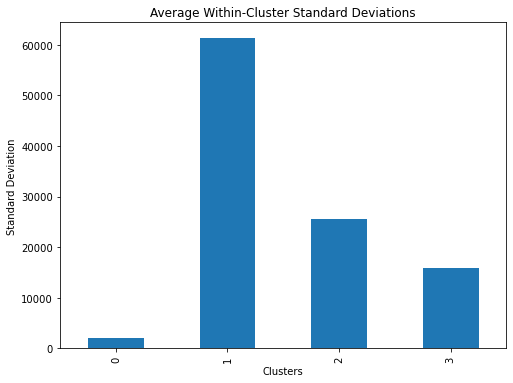

In [ ]:
import matplotlib.pyplot as plt

# Bar plot for standard deviations
std_deviation.mean(axis=1).plot(kind='bar', figsize=(8, 6))
plt.title("Average Within-Cluster Standard Deviations")
plt.ylabel("Standard Deviation")
plt.xlabel("Clusters")
plt.show()

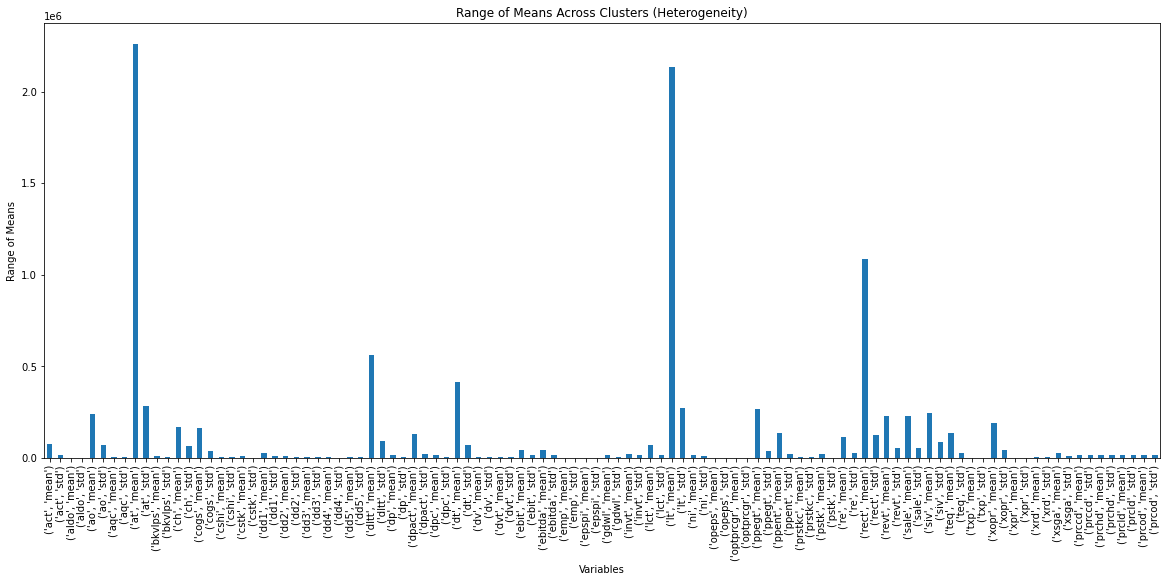

In [ ]:
# Bar plot for range of means
mean_differences.plot(kind='bar', figsize=(20, 8))
plt.title("Range of Means Across Clusters (Heterogeneity)")
plt.ylabel("Range of Means")
plt.xlabel("Variables")
plt.show()

In [ ]:
data = pd.read_excel('CleanedMeansDifferences.xlsx')

In [ ]:
data.head()

,Variables,Range,Name
0,"('ao', 'mean')",2.395266e+05,Operating Assets_Mean
1,"('at', 'mean')",2.261501e+06,Total Assets_Mean
2,"('at', 'std')",2.801768e+05,Total Assets_STD
3,"('ch', 'mean')",1.685301e+05,Cash and Cash Equivalents_Mean
4,"('cogs', 'mean')",1.639777e+05,Cost of Goods Sold_Mean


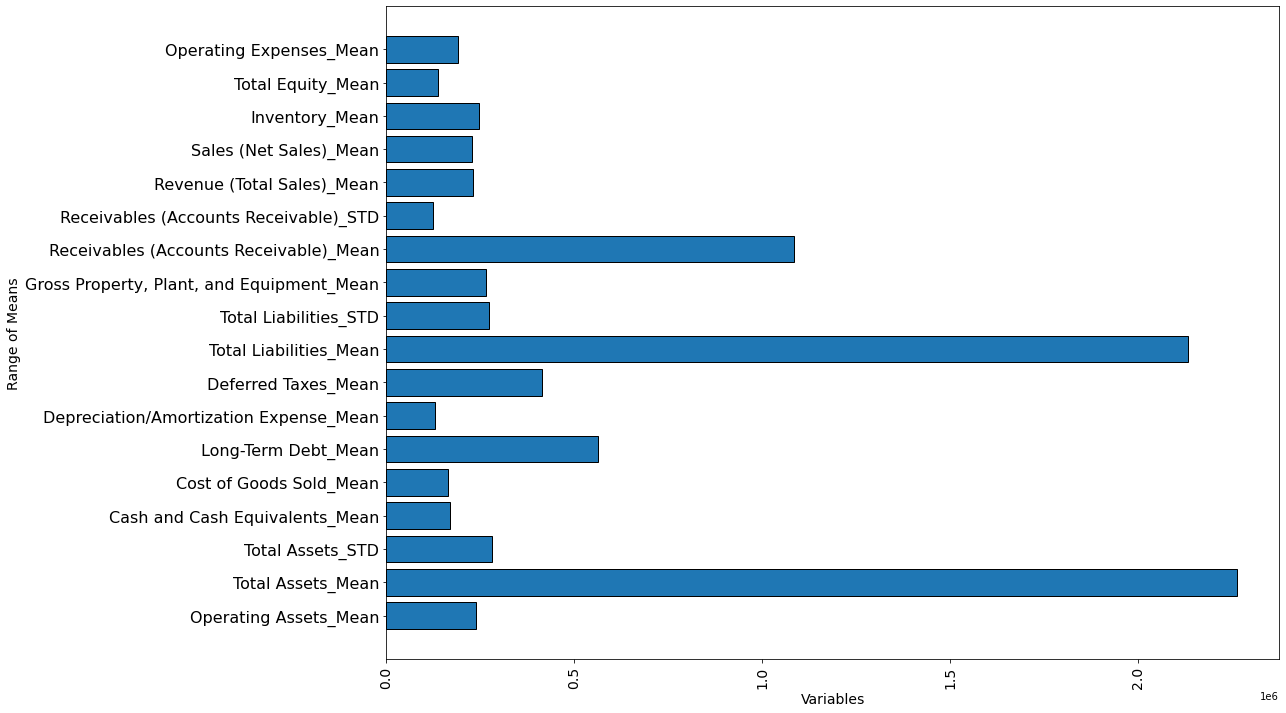

In [ ]:
# Bar plot for range of means
plt.figure(figsize=(16, 12))  # Adjust figure size
plt.barh(data['Name'], data['Range'], edgecolor='black')
plt.xlabel('Variables', fontsize=14)
plt.ylabel('Range of Means', fontsize=14)
plt.yticks(fontsize=16) 
plt.xticks(rotation=0, fontsize=14)
plt.show()

In [ ]:
# Helper function to apply KMeans clustering on a 3-variable subset and plot the results
def perform_kmeans_clustering(df, columns, n_clusters=3):
    # Select the 3 columns for clustering
    data = df[columns].dropna()  # Dropping NA values for simplicity
    
    # Apply K-Means clustering
    kmeans = KMeans(n_clusters=n_clusters, random_state=42)
    labels = kmeans.fit_predict(data)
    
 # Add labels to the DataFrame for visualization
    data['Cluster'] = labels
    
    # Plot the clusters in a 3D scatter plot
    fig = plt.figure(figsize=(10, 7))
    ax = fig.add_subplot(111, projection='3d')
    ax.scatter(data[columns[0]], data[columns[1]], data[columns[2]], c=labels, cmap='viridis')
    ax.set_xlabel(columns[0])
    ax.set_ylabel(columns[1])
    ax.set_zlabel(columns[2])
    plt.title(f"K-Means Clustering using {columns[0]}, {columns[1]}, and {columns[2]}")
    plt.show()
    
    return labels

# Cluster profile for 10 financial ratios and other unused variables

In [ ]:

df.head()

,gvkey,conm,fyear,indfmt,datafmt,tic,fyr,sppe,exchg,cik,...,Asset_Turnover_Ratio,Return_on_Assets_ROA,Return_on_Equity_ROE,Gross_Profit_Margin,Earnings_per_Share_EPS,Cash_Ratio,Inventory_Turnover_Ratio,Quick_Ratio,Cash_Flow_to_Debt_Ratio,Cluster
0,1004,AAR CORP,2022,INDL,STD,AIR,5,68.471974,11.0,1750.0,...,1.100411,0.025077,0.612659,0.187891,1.181590e-06,0.125793,2.485833,1.168924,2.124325,0
1,1045,AMERICAN AIRLINES GROUP INC,2023,INDL,STD,AAL,12,230.000000,14.0,6201.0,...,0.708988,0.014442,3.589565,0.262591,1.263272e-06,0.033648,18.939357,0.582799,0.523626,3
2,1050,CECO ENVIRONMENTAL CORP,2023,INDL,STD,CECO,12,68.471974,14.0,3197.0,...,0.784196,0.003576,0.024505,0.327111,4.819751e-08,0.266724,3.676639,1.037107,1.061428,0
3,1062,ASA GOLD AND PRECIOUS METALS,2023,FS,STD,ASA,11,68.471974,11.0,1230869.0,...,0.006554,0.030375,0.131674,0.577968,4.673924e-07,0.017190,0.005915,0.727621,20.302158,0
4,1075,PINNACLE WEST CAPITAL CORP,2023,INDL,STD,PNW,12,23.400000,11.0,764622.0,...,0.200220,0.026443,21.235671,0.371283,4.382041e-06,0.066058,6.970897,0.511584,0.185619,0


In [ ]:
# Replace `Cluster` with the column name that stores your cluster assignments
grouped = df.groupby('Cluster')

In [ ]:
print(list(df.columns))

['gvkey', 'conm', 'fyear', 'indfmt', 'datafmt', 'tic', 'fyr', 'sppe', 'exchg', 'cik', 'costat', 'ggroup', 'gind', 'gsector', 'gsubind', 'idbflag', 'incorp', 'naics', 'sic', 'spcindcd', "('act', 'mean')", "('act', 'std')", "('aldo', 'mean')", "('aldo', 'std')", "('ao', 'mean')", "('ao', 'std')", "('aqc', 'mean')", "('aqc', 'std')", "('at', 'mean')", "('at', 'std')", "('bkvlps', 'mean')", "('bkvlps', 'std')", "('ch', 'mean')", "('ch', 'std')", "('cogs', 'mean')", "('cogs', 'std')", "('cshi', 'mean')", "('cshi', 'std')", "('cstk', 'mean')", "('cstk', 'std')", "('dd1', 'mean')", "('dd1', 'std')", "('dd2', 'mean')", "('dd2', 'std')", "('dd3', 'mean')", "('dd3', 'std')", "('dd4', 'mean')", "('dd4', 'std')", "('dd5', 'mean')", "('dd5', 'std')", "('dltt', 'mean')", "('dltt', 'std')", "('dp', 'mean')", "('dp', 'std')", "('dpact', 'mean')", "('dpact', 'std')", "('dpc', 'mean')", "('dpc', 'std')", "('dt', 'mean')", "('dt', 'std')", "('dv', 'mean')", "('dv', 'std')", "('dvt', 'mean')", "('dvt', 's

In [ ]:
# Step 3: Compute Mean, Median, and Standard Deviation for Financial Ratios and Other Variables
# Add the 11 ratios and any additional continuous variables to analyze

selected_columns = [
    'Debt_to_Equity_Ratio', 'Current_Ratio', 'Asset_Turnover_Ratio', 
    'Return_on_Assets_ROA', 'Return_on_Equity_ROE', 'Gross_Profit_Margin', 
    'Earnings_per_Share_EPS', 'Cash_Ratio', 'Inventory_Turnover_Ratio', 
    'Quick_Ratio', 'Cash_Flow_to_Debt_Ratio'
]

selected_columns_full = [
    'Debt_to_Equity_Ratio', 'Current_Ratio', 'Asset_Turnover_Ratio', 
    'Return_on_Assets_ROA', 'Return_on_Equity_ROE', 'Gross_Profit_Margin', 
    'Earnings_per_Share_EPS', 'Cash_Ratio', 'Inventory_Turnover_Ratio', 
    'Quick_Ratio', 'Cash_Flow_to_Debt_Ratio', 
    "('aldo', 'mean')", "('aldo', 'std')", "('ao', 'mean')", "('ao', 'std')", "('aqc', 'mean')", "('aqc', 'std')",
    "('bkvlps', 'mean')", "('bkvlps', 'std')", "('ch', 'mean')", "('ch', 'std')",
    "('cstk', 'mean')", "('cstk', 'std')", "('dd1', 'mean')", "('dd1', 'std')", "('dd2', 'mean')", "('dd2', 'std')", 
    "('dd3', 'mean')", "('dd3', 'std')", "('dd4', 'mean')", "('dd4', 'std')", "('dd5', 'mean')", "('dd5', 'std')",
    "('dp', 'mean')", "('dp', 'std')", "('dpact', 'mean')", "('dpact', 'std')", "('dpc', 'mean')", "('dpc', 'std')",
     "('dv', 'mean')", "('dv', 'std')", "('dvt', 'mean')", "('dvt', 'std')", "('ebit', 'mean')", "('ebit', 'std')",
    "('ebitda', 'mean')", "('ebitda', 'std')", "('emp', 'mean')", "('emp', 'std')", "('epspi', 'mean')", "('epspi', 'std')",
     "('gdwl', 'mean')", "('gdwl', 'std')",
    "('opeps', 'mean')", "('opeps', 'std')", "('optprcgr', 'mean')", "('optprcgr', 'std')", "('ppegt', 'mean')", "('ppegt', 'std')", 
    "('prstkc', 'mean')", "('prstkc', 'std')", "('pstk', 'mean')", "('pstk', 'std')", "('re', 'mean')", "('re', 'std')",
    "('siv', 'mean')", "('siv', 'std')", "('teq', 'mean')", "('teq', 'std')", "('txp', 'mean')", "('txp', 'std')", "('xopr', 'mean')", 
    "('xopr', 'std')", "('xpr', 'mean')", "('xpr', 'std')", "('xrd', 'mean')", "('xrd', 'std')", "('xsga', 'mean')", "('xsga', 'std')",
    "('prccd', 'mean')", "('prccd', 'std')", "('prchd', 'mean')", "('prchd', 'std')", "('prcld', 'mean')", "('prcld', 'std')",
    "('prcod', 'mean')", "('prcod', 'std')"
    
]
selected_columns_group1 = ["('aldo', 'mean')", "('aldo', 'std')", "('ao', 'mean')", "('ao', 'std')", "('aqc', 'mean')", "('aqc', 'std')",
    "('bkvlps', 'mean')", "('bkvlps', 'std')", "('ch', 'mean')", "('ch', 'std')"]
selected_columns_group2 = ["('cstk', 'mean')", "('cstk', 'std')", "('dd1', 'mean')", "('dd1', 'std')", "('dd2', 'mean')", "('dd2', 'std')", 
    "('dd3', 'mean')", "('dd3', 'std')", "('dd4', 'mean')", "('dd4', 'std')", "('dd5', 'mean')", "('dd5', 'std')"]
selected_columns_group3 = [ "('dp', 'mean')", "('dp', 'std')", "('dpact', 'mean')", "('dpact', 'std')", "('dpc', 'mean')", "('dpc', 'std')",
     "('dv', 'mean')", "('dv', 'std')", "('dvt', 'mean')", "('dvt', 'std')", "('ebit', 'mean')", "('ebit', 'std')"]
selected_columns_group4 = ["('ebitda', 'mean')", "('ebitda', 'std')", "('emp', 'mean')", "('emp', 'std')", "('epspi', 'mean')", "('epspi', 'std')",
     "('gdwl', 'mean')", "('gdwl', 'std')"]
selected_columns_group5 =["('opeps', 'mean')", "('opeps', 'std')", "('optprcgr', 'mean')", "('optprcgr', 'std')", "('ppegt', 'mean')", "('ppegt', 'std')", 
    "('prstkc', 'mean')", "('prstkc', 'std')", "('pstk', 'mean')", "('pstk', 'std')", "('re', 'mean')", "('re', 'std')"]
selected_columns_group6 =["('siv', 'mean')", "('siv', 'std')", "('teq', 'mean')", "('teq', 'std')", "('txp', 'mean')", "('txp', 'std')", "('xopr', 'mean')", 
    "('xopr', 'std')", "('xpr', 'mean')", "('xpr', 'std')", "('xrd', 'mean')", "('xrd', 'std')", "('xsga', 'mean')", "('xsga', 'std')"]
selected_columns_group7 = ["('prccd', 'mean')", "('prccd', 'std')", "('prchd', 'mean')", "('prchd', 'std')", "('prcld', 'mean')", "('prcld', 'std')",
    "('prcod', 'mean')", "('prcod', 'std')"]





# Compute the statistics
summary_stats_full = grouped[selected_columns_full].agg(['mean', 'median', 'std'])
print(summary_stats_full)



        Debt_to_Equity_Ratio                             Current_Ratio  \
                        mean        median           std          mean   
Cluster                                                                  
0                1639.084454    123.447101  23022.639618     30.629323   
1               29079.240645  26860.483125  12971.738219      1.265162   
2                2059.050792   2181.903653   2035.557096      1.171007   
3                8700.121672   1005.033097  47612.033263      1.184941   

                               Asset_Turnover_Ratio                           \
           median          std                 mean    median            std   
Cluster                                                                        
0        1.265162  1004.461984          7164.397699  0.291495  229872.367506   
1        1.265162     0.000000             0.033829  0.031632       0.011361   
2        1.123620     0.522210             0.747314  0.622648       0.495571   
3

In [ ]:
summary_stats.to_csv("ZX_full_cluster_statistics.csv")

In [ ]:
selected_columns_group1 = ["('aldo', 'mean')", "('aldo', 'std')", "('ao', 'mean')", "('ao', 'std')", "('aqc', 'mean')", "('aqc', 'std')",
    "('bkvlps', 'mean')", "('bkvlps', 'std')", "('ch', 'mean')", "('ch', 'std')"]
selected_columns_group2 = ["('cstk', 'mean')", "('cstk', 'std')", "('dd1', 'mean')", "('dd1', 'std')", "('dd2', 'mean')", "('dd2', 'std')", 
    "('dd3', 'mean')", "('dd3', 'std')", "('dd4', 'mean')", "('dd4', 'std')", "('dd5', 'mean')", "('dd5', 'std')"]
selected_columns_group3 = [ "('dp', 'mean')", "('dp', 'std')", "('dpact', 'mean')", "('dpact', 'std')", "('dpc', 'mean')", "('dpc', 'std')",
     "('dv', 'mean')", "('dv', 'std')", "('dvt', 'mean')", "('dvt', 'std')", "('ebit', 'mean')", "('ebit', 'std')"]
selected_columns_group4 = ["('ebitda', 'mean')", "('ebitda', 'std')", "('emp', 'mean')", "('emp', 'std')", "('epspi', 'mean')", "('epspi', 'std')",
     "('gdwl', 'mean')", "('gdwl', 'std')"]
selected_columns_group5 =["('opeps', 'mean')", "('opeps', 'std')", "('optprcgr', 'mean')", "('optprcgr', 'std')", "('ppegt', 'mean')", "('ppegt', 'std')", 
    "('prstkc', 'mean')", "('prstkc', 'std')", "('pstk', 'mean')", "('pstk', 'std')", "('re', 'mean')", "('re', 'std')"]
selected_columns_group6 =["('siv', 'mean')", "('siv', 'std')", "('teq', 'mean')", "('teq', 'std')", "('txp', 'mean')", "('txp', 'std')", "('xopr', 'mean')", 
    "('xopr', 'std')", "('xpr', 'mean')", "('xpr', 'std')", "('xrd', 'mean')", "('xrd', 'std')", "('xsga', 'mean')", "('xsga', 'std')"]
selected_columns_group7 = ["('prccd', 'mean')", "('prccd', 'std')", "('prchd', 'mean')", "('prchd', 'std')", "('prcld', 'mean')", "('prcld', 'std')",
    "('prcod', 'mean')", "('prcod', 'std')"]

# Compute the statistics
summary_stats_group1 = grouped[selected_columns_group1].agg(['mean', 'median', 'std'])
summary_stats_group2 = grouped[selected_columns_group2].agg(['mean', 'median', 'std'])
summary_stats_group3 = grouped[selected_columns_group3].agg(['mean', 'median', 'std'])
summary_stats_group4 = grouped[selected_columns_group4].agg(['mean', 'median', 'std'])
summary_stats_group5 = grouped[selected_columns_group5].agg(['mean', 'median', 'std'])
summary_stats_group6 = grouped[selected_columns_group6].agg(['mean', 'median', 'std'])
summary_stats_group7 = grouped[selected_columns_group7].agg(['mean', 'median', 'std'])

In [ ]:
cleaned_columns = ["('ao', 'mean')", "('ao', 'std')","('ch', 'mean')", "('ch', 'std')", "('dd1', 'mean')", "('dd2', 'mean')",
                  "('dd3', 'mean')",  "('dd4', 'mean')", "('dd5', 'mean')", "('dd5', 'std')", "('ebit', 'mean')", "('dpact', 'mean')",
                   "('cstk', 'mean')", "('ebitda', 'mean')", "('ebitda', 'std')", "('gdwl', 'mean')",  "('re', 'mean')",
                   "('ppegt', 'mean')", "('siv', 'mean')", "('siv', 'std')","('teq', 'mean')", "('xopr', 'mean')",
                   "('prccd', 'mean')", "('prccd', 'std')", "('prchd', 'mean')", "('prchd', 'std')", "('prcld', 'mean')", 
                   "('prcld', 'std')","('prcod', 'mean')", "('prcod', 'std')"
                  ]
summary_stats_cleaned = grouped[cleaned_columns].agg(['mean', 'median', 'std'])

In [ ]:
cleaned_columns2 = ["('ao', 'mean')", "('ao', 'std')","('ch', 'mean')", "('ch', 'std')", "('ebit', 'mean')", "('dpact', 'mean')",
                    "('ebitda', 'mean')",   "('re', 'mean')",
                   "('ppegt', 'mean')", "('siv', 'mean')", "('siv', 'std')","('teq', 'mean')", "('xopr', 'mean')",
                  ]
summary_stats_cleaned2 = grouped[cleaned_columns2].agg(['mean', 'median', 'std'])

In [ ]:
summary_stats_cleaned2.to_csv("ZX_cleaned2_cluster_statistics.csv")

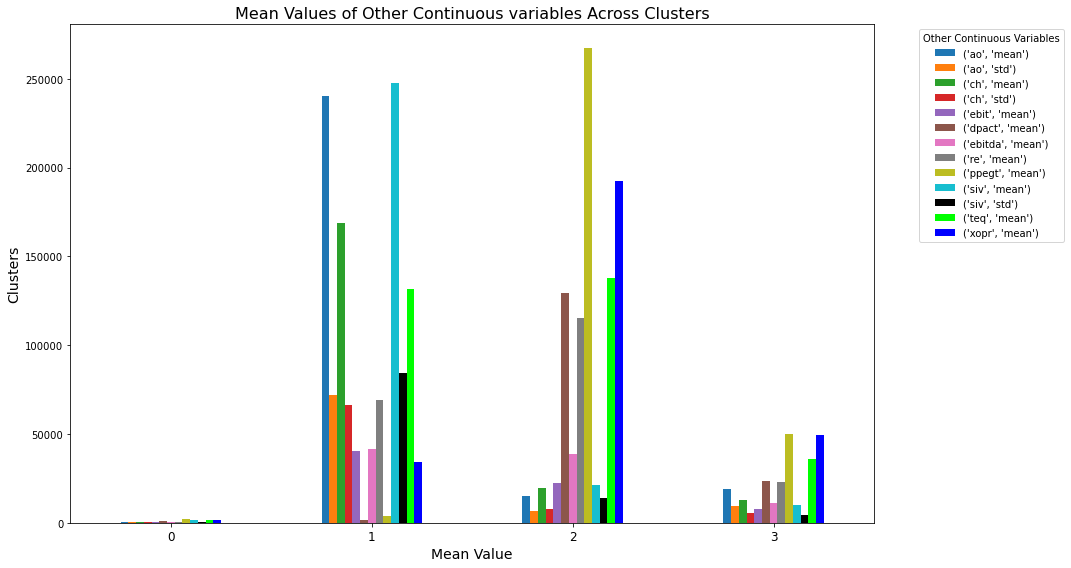

In [ ]:
import matplotlib.pyplot as plt

# Step 1: Select the relevant data (means for each ratio)
mean_values_cleaned2 = summary_stats_cleaned2.xs('mean', axis=1, level=1)


unique_colors = [
    '#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd',
    '#8c564b', '#e377c2', '#7f7f7f', '#bcbd22', '#17becf',
    '#000000',  '#00ff00', '#0000ff', '#ffff00',
    '#ff00ff', '#00ffff', '#ffa500', '#800080', '#808000'
]  # Adjust/add more colors if necessary

# Step 2: Plot a bar plot for each ratio
mean_values_cleaned2.plot(kind='bar', color=unique_colors, figsize=(15, 8), legend=True)

# Step 3: Customize the plot
plt.title("Mean Values of Other Continuous variables Across Clusters", fontsize=16)
plt.xlabel("Mean Value", fontsize=14)
plt.ylabel("Clusters", fontsize=14)
plt.xticks(rotation=0, fontsize=12)
plt.legend(title="Other Continuous Variables", bbox_to_anchor=(1.05, 1), loc='upper left')

# Show the plot
plt.tight_layout()
plt.show()


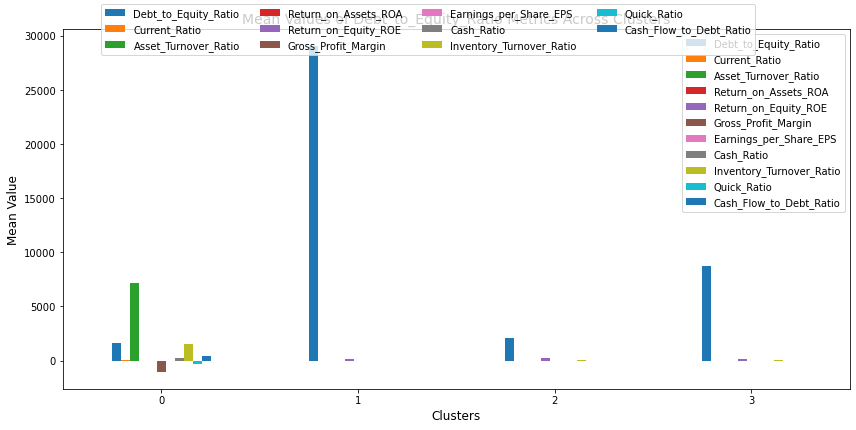

In [ ]:
financial_ratios = [
    'Debt_to_Equity_Ratio', 'Current_Ratio', 'Asset_Turnover_Ratio', 
    'Return_on_Assets_ROA', 'Return_on_Equity_ROE', 'Gross_Profit_Margin', 
    'Earnings_per_Share_EPS', 'Cash_Ratio', 'Inventory_Turnover_Ratio', 
    'Quick_Ratio', 'Cash_Flow_to_Debt_Ratio'
]
# mean_values = summary_stats.xs('mean', axis=1, level=1)

# Define variable categories (e.g., financial ratios, profitability metrics, etc.)
categories = [financial_ratios]  # Add more categories if applicable

# Create subplots based on the number of categories
fig, axes = plt.subplots(len(categories), 1, figsize=(12, len(categories) * 6))  # Dynamic sizing

# If there's only one category, axes won't be iterable; handle that
if len(categories) == 1:
    axes = [axes]

# Plot each category in a separate subplot
for i, category in enumerate(categories):
    # Select mean values for the current category
    category_means = summary_stats.xs('mean', axis=1, level=1)[category]
    
    # Plot in the current axis
    category_means.plot(kind='bar', ax=axes[i], legend=(i == 0))  # Legend only for the first plot
    axes[i].set_title(f"Mean Values of {category[0]} Metrics Across Clusters", fontsize=14)
    axes[i].set_xlabel("Clusters", fontsize=12)
    axes[i].set_ylabel("Mean Value", fontsize=12)
    axes[i].tick_params(axis='x', rotation=0)

# Adjust layout and add a single legend if needed
fig.legend(category_means.columns, loc='upper center', ncol=4, fontsize=10)
plt.tight_layout()
plt.show()


# Heat Map

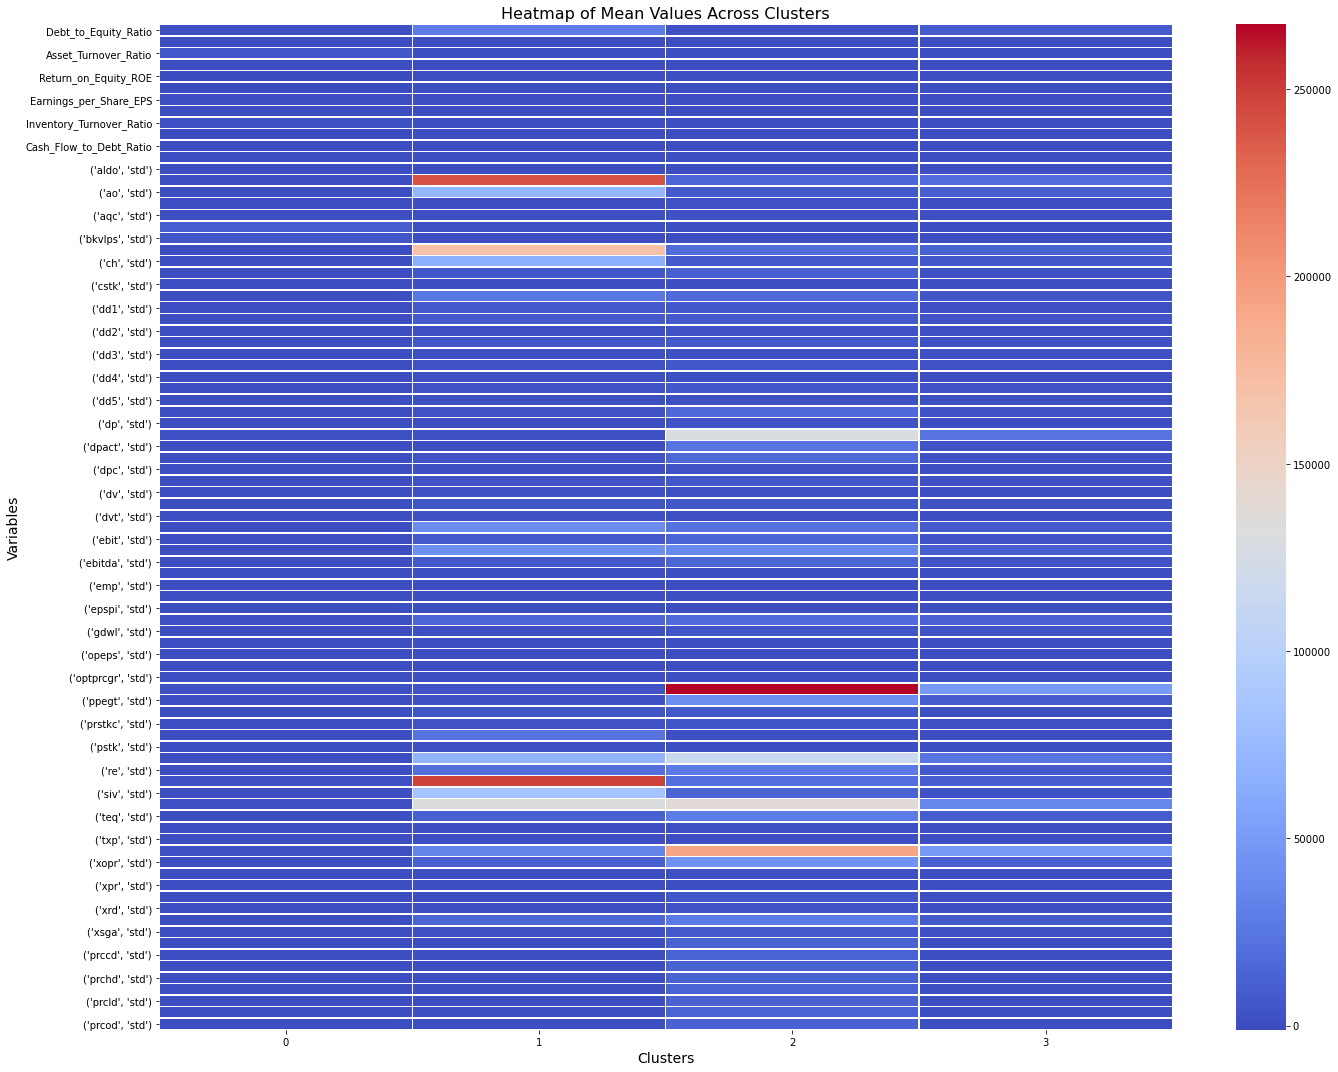

In [ ]:
import seaborn as sns
import pandas as pd

# Select mean values for all variables
heatmap_data = summary_stats_full.xs('mean', axis=1, level=1).T  # Transpose for better readability

# Create a heatmap
plt.figure(figsize=(20, 15))
sns.heatmap(heatmap_data, annot=False, cmap='coolwarm', cbar=True, linewidths=0.5)
plt.title("Heatmap of Mean Values Across Clusters", fontsize=16)
plt.xlabel("Clusters", fontsize=14)
plt.ylabel("Variables", fontsize=14)
plt.tight_layout()
plt.show()


# Box-Plot

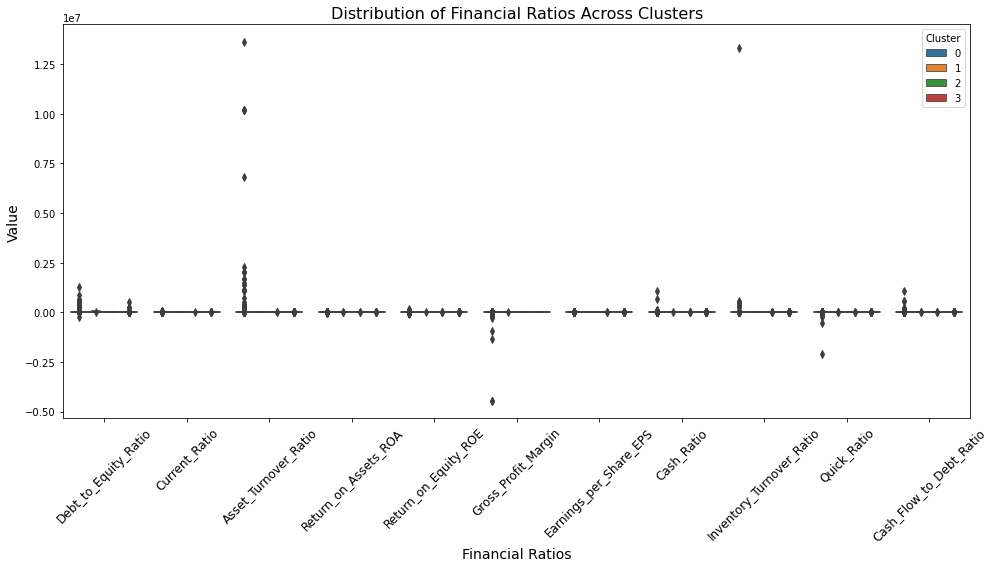

In [ ]:
# Step 1: Melt the dataset into a long format for easier plotting
melted_data = df.melt(id_vars='Cluster', value_vars=[
    'Debt_to_Equity_Ratio', 'Current_Ratio', 'Asset_Turnover_Ratio',
    'Return_on_Assets_ROA', 'Return_on_Equity_ROE', 'Gross_Profit_Margin',
    'Earnings_per_Share_EPS', 'Cash_Ratio', 'Inventory_Turnover_Ratio',
    'Quick_Ratio', 'Cash_Flow_to_Debt_Ratio'
], var_name='Financial Ratio', value_name='Value')

# Step 2: Create box plots
import seaborn as sns
plt.figure(figsize=(14, 8))
sns.boxplot(data=melted_data, x='Financial Ratio', y='Value', hue='Cluster')

# Step 3: Customize the plot
plt.title("Distribution of Financial Ratios Across Clusters", fontsize=16)
plt.xlabel("Financial Ratios", fontsize=14)
plt.ylabel("Value", fontsize=14)
plt.xticks(rotation=45, fontsize=12)
plt.legend(title="Cluster", loc='upper right')

# Show the plot
plt.tight_layout()
plt.show()


# Radar Chart

In [ ]:
import os

In [ ]:
data1 = pd.read_excel('Data for Radar Chart.xlsx')
data1.head()

,Variable,Mean,Median,Standard Deviation
0,Debt_to_Equity_Ratio,1639.084454,123.447101,23022.639618
1,Current_Ratio,30.629323,1.265162,1004.461984
2,Asset_Turnover_Ratio,7164.397699,0.291495,229872.367506
3,Return_on_Assets_ROA,-6.989207,0.017627,445.850978
4,Return_on_Equity_ROE,-50.512508,1.993336,2447.994587


In [ ]:
from sklearn.preprocessing import MinMaxScaler

# Normalize data (excluding the 'Variable' column)
scaler = MinMaxScaler()
normalized_data = scaler.fit_transform(data1.iloc[:, 1:])

# Add the normalized data back to the DataFrame
df_normalized = pd.DataFrame(normalized_data, columns=data1.columns[1:])
df_normalized["Variable"] = data1["Variable"]
df_normalized = df_normalized.set_index("Variable")

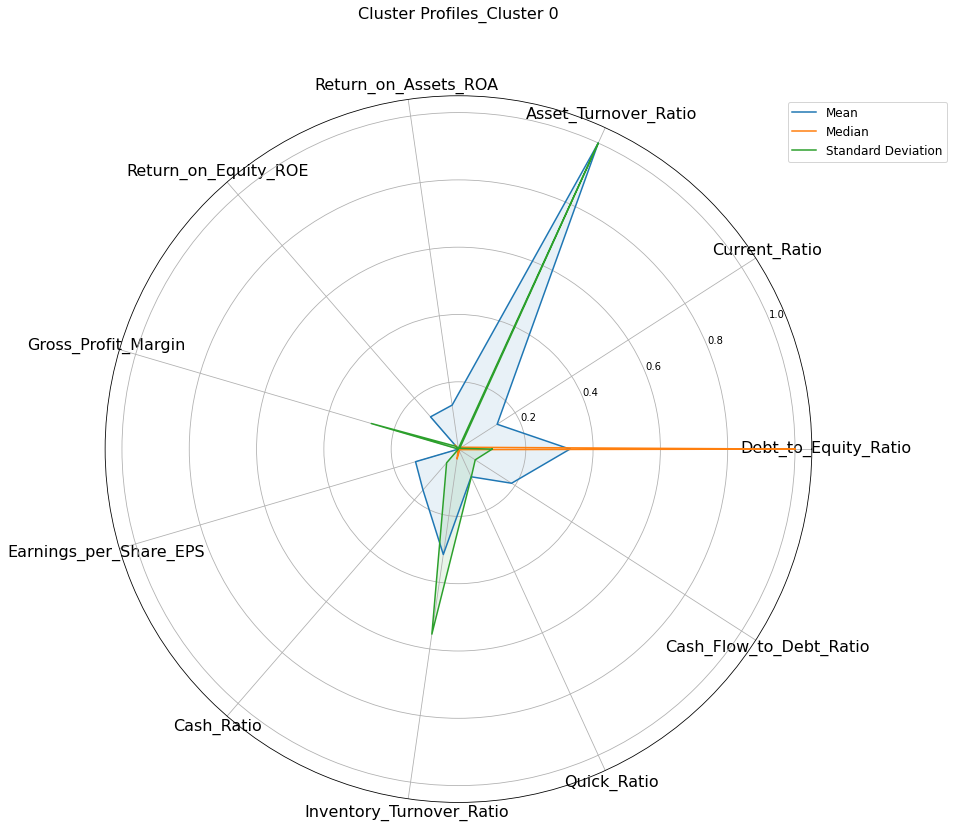

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Function to plot radar chart
def plot_radar_chart(data1, clusters):
    labels = data1.index
    num_vars = len(labels)

    # Compute angle for each axis
    angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
    angles += angles[:1]  # Close the loop

    fig, ax = plt.subplots(figsize=(18, 13), subplot_kw=dict(polar=True))

    for cluster in clusters:
        values = data1[cluster].tolist()
        values += values[:1]  # Close the loop
        ax.plot(angles, values, label=cluster)
        ax.fill(angles, values, alpha=0.1)

    # Add labels
    ax.set_yticks([0.2, 0.4, 0.6, 0.8, 1.0])  # Adjust for normalization
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(labels, fontsize=16, ha='center')


    ax.legend(loc='upper right', bbox_to_anchor=(1.2, 1.0), fontsize=12)
    plt.title("Cluster Profiles_Cluster 0", size=16, y=1.1)
    plt.show()

# Plot radar chart for clusters
plot_radar_chart(df_normalized, data1.columns[1:])


## Appendix - Visualization for cluster

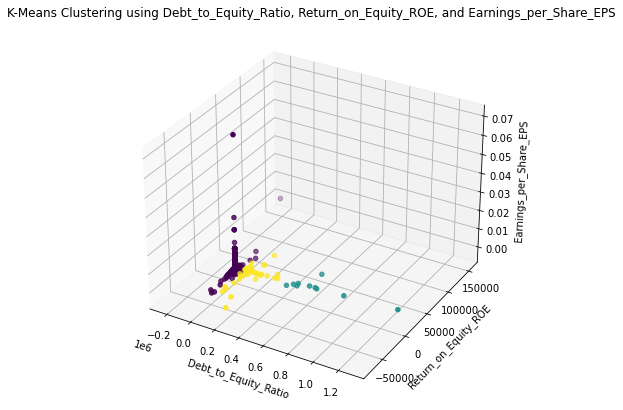

array([0, 0, 0, ..., 0, 0, 0], dtype=int32)

In [ ]:
perform_kmeans_clustering(df, selected_columns, n_clusters=3)

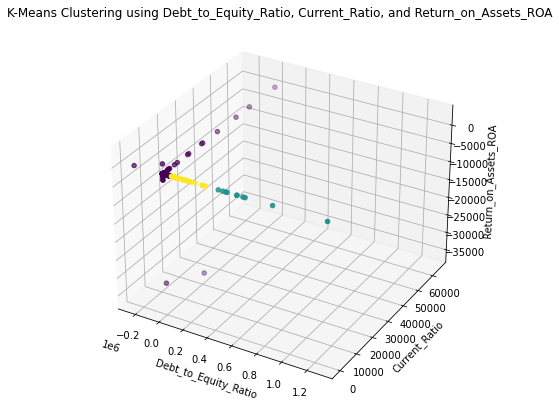

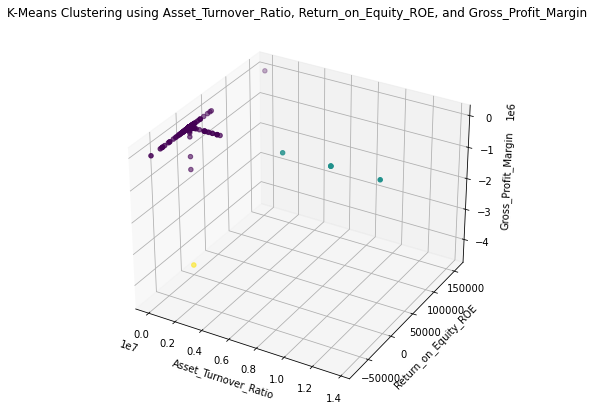

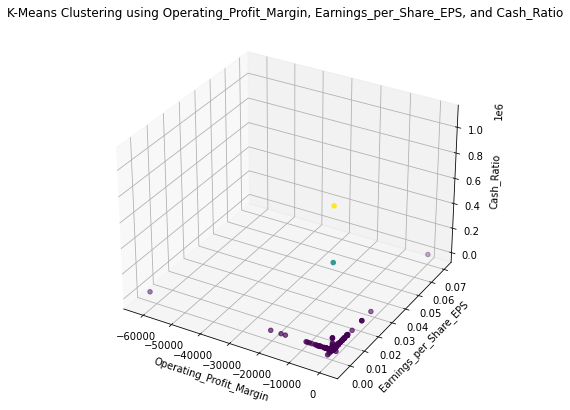

In [ ]:
# Define three combinations for 3-variable clustering
combinations = [
    ['Debt_to_Equity_Ratio', 'Current_Ratio', 'Return_on_Assets_ROA'],
    ['Asset_Turnover_Ratio', 'Return_on_Equity_ROE', 'Gross_Profit_Margin'],
    ['Operating_Profit_Margin', 'Earnings_per_Share_EPS', 'Cash_Ratio']
]

# Perform K-Means clustering for each combination and plot the results
for combo in combinations:
    perform_kmeans_clustering(df, combo, n_clusters=3)